# Phase 2 EDA - Product, Promotion, Return, Inventory Insights

Workspace: `group_job`

Mục tiêu notebook này là biến draft câu hỏi thành các phân tích có thể kiểm chứng bằng dữ liệu. Trọng tâm là sản phẩm: sản phẩm nào đóng góp doanh thu/lợi nhuận, bán tốt vào thời điểm nào, phụ thuộc promotion ra sao, được review/trả hàng như thế nào, khu vực nào mua nhiều, và tồn kho có sẵn trước các tháng cao điểm hay không.

Notebook chỉ dùng dữ liệu được cung cấp trong `data/`. Các góc không có dữ liệu hỗ trợ, ví dụ TikTok cụ thể, marketing spend, hoặc causal ROI của promotion, được ghi rõ là không kết luận.


## 0. Từ draft sang câu hỏi EDA khả thi

Draft ban đầu xoay quanh chuỗi: **top sản phẩm đóng góp lợi nhuận -> bán khi nào -> bán qua kênh nào -> bán qua marketing/promotion nào -> tối ưu season, platform, promotion cost**.

Trong dữ liệu có thể làm tốt các câu hỏi sau:

1. Sản phẩm/danh mục nào đóng góp nhiều nhất vào doanh thu và gross margin? Top bán chạy theo số lượng có khác top lợi nhuận không?
2. Mỗi danh mục và nhóm sản phẩm chủ lực đạt "thời gian vàng" vào tháng nào?
3. Doanh thu/lợi nhuận đến từ kênh đặt hàng nào (`order_source`) và mức phụ thuộc promotion của từng sản phẩm là bao nhiêu?
4. Sản phẩm nào chỉ bán mạnh khi có promotion, nhưng margin thấp hoặc âm?
5. Sản phẩm/danh mục nào bị rò rỉ doanh thu qua hoàn hàng/refund, và review có cảnh báo gì không?
6. Khu vực nào thường mua từng danh mục/sản phẩm?
7. Tồn kho có sẵn trong/tháng trước mùa cao điểm không? Sản phẩm nào vừa stockout vừa có nhu cầu cao, và sản phẩm nào tồn lâu/tồn nhiều?

Các câu hỏi **không kết luận cứng** vì thiếu dữ liệu:

- "Sản phẩm lợi nhuận cao đang được bán trên TikTok không?" Không có trường TikTok/platform cụ thể; chỉ có `order_source`, `promo_channel`, `traffic_source`.
- "Tối ưu chi phí marketing/promotion ROI" Không có marketing spend hoặc campaign cost.
- "Promotion gây ra tăng trưởng bao nhiêu?" Dữ liệu quan sát không có nhóm control/randomization; notebook chỉ đo phụ thuộc promotion và pattern trước/sau mô tả.


## 1. Setup, load dữ liệu, kiểm tra coverage


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["savefig.bbox"] = "tight"
pd.options.display.max_columns = 80
pd.options.display.float_format = "{:,.4f}".format

ROOT = Path.cwd().resolve()
while not (ROOT / "data").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATA = ROOT / "data"
WORK = ROOT / "group_job"
FIG = WORK / "figures"
TABLE = WORK / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TABLE.mkdir(parents=True, exist_ok=True)

def savefig(name: str) -> Path:
    path = FIG / name
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    return path

def fmt_money(v: float) -> str:
    if pd.isna(v):
        return ""
    av = abs(float(v))
    if av >= 1e9:
        return f"{v / 1e9:,.2f}B"
    if av >= 1e6:
        return f"{v / 1e6:,.2f}M"
    if av >= 1e3:
        return f"{v / 1e3:,.2f}K"
    return f"{v:,.2f}"

def fmt_pct(v: float) -> str:
    if pd.isna(v):
        return ""
    return f"{100 * float(v):.1f}%"

def view_table(df: pd.DataFrame, money_cols=(), pct_cols=(), int_cols=(), n: int | None = None) -> pd.DataFrame:
    out = df.head(n).copy() if n else df.copy()
    for col in money_cols:
        if col in out:
            out[col] = out[col].map(fmt_money)
    for col in pct_cols:
        if col in out:
            out[col] = out[col].map(fmt_pct)
    for col in int_cols:
        if col in out:
            out[col] = out[col].map(lambda x: f"{int(x):,}" if pd.notna(x) else "")
    return out

print("Repo root:", ROOT)
print("Data dir :", DATA)
print("Output   :", WORK)


Repo root: /home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm
Data dir : /home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm/data
Output   : /home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm/group_job


In [2]:
DATE_COLS = {
    "orders": ["order_date"],
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
    "sales": ["Date"],
    "sample_submission": ["Date"],
}

DTYPE = {
    "order_items": {"promo_id": "string", "promo_id_2": "string"},
    "promotions": {"promo_id": "string"},
}

def load_csv(name: str) -> pd.DataFrame:
    return pd.read_csv(
        DATA / f"{name}.csv",
        parse_dates=DATE_COLS.get(name, []),
        dtype=DTYPE.get(name),
        low_memory=False,
    )

sales = load_csv("sales")
orders = load_csv("orders")
order_items = load_csv("order_items")
products = load_csv("products")
customers = load_csv("customers")
promotions = load_csv("promotions")
payments = load_csv("payments")
shipments = load_csv("shipments")
returns = load_csv("returns")
reviews = load_csv("reviews")
geography = load_csv("geography")
inventory = load_csv("inventory")
web = load_csv("web_traffic")

tables = {
    "sales": sales,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "customers": customers,
    "promotions": promotions,
    "payments": payments,
    "shipments": shipments,
    "returns": returns,
    "reviews": reviews,
    "geography": geography,
    "inventory": inventory,
    "web_traffic": web,
}

summary_rows = []
for name, df in tables.items():
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    summary_rows.append(
        {
            "table": name,
            "rows": len(df),
            "cols": df.shape[1],
            "date_min": min((df[c].min() for c in date_cols), default=pd.NaT),
            "date_max": max((df[c].max() for c in date_cols), default=pd.NaT),
            "max_missing_pct": df.isna().mean().max() if len(df.columns) else 0,
        }
    )

data_summary = pd.DataFrame(summary_rows).sort_values("rows", ascending=False)
display(view_table(data_summary, pct_cols=["max_missing_pct"], int_cols=["rows", "cols"]))
data_summary.to_csv(TABLE / "00_data_summary.csv", index=False)


,table,rows,cols,date_min,date_max,max_missing_pct
2,order_items,"714,669",7,NaT,NaT,100.0%
1,orders,"646,945",8,2012-07-04,2022-12-31,0.0%
6,payments,"646,945",4,NaT,NaT,0.0%
7,shipments,"566,067",4,2012-07-04,2022-12-31,0.0%
4,customers,"121,930",7,2012-01-17,2022-12-31,0.0%
9,reviews,"113,551",7,2012-07-10,2022-12-31,0.0%
11,inventory,"60,247",17,2012-07-31,2022-12-31,0.0%
10,geography,"39,948",4,NaT,NaT,0.0%
8,returns,"39,939",7,2012-07-11,2022-12-31,0.0%
0,sales,"3,833",3,2012-07-04,2022-12-31,0.0%


In [3]:
feasibility = pd.DataFrame(
    [
        {
            "question": "Top sản phẩm theo doanh thu, số lượng, gross margin",
            "sources": "order_items + orders + products + sales",
            "verdict": "Làm được",
            "caveat": "Gross margin dùng unit_price sau giảm giá trừ product cogs; chưa trừ marketing/logistics.",
        },
        {
            "question": "Bán chạy/lợi nhuận cao vào thời điểm nào",
            "sources": "orders.order_date + order_items + products",
            "verdict": "Làm được",
            "caveat": "Phân tích theo tháng/ngày; inventory chỉ có snapshot cuối tháng.",
        },
        {
            "question": "Bán qua kênh nào",
            "sources": "orders.order_source, web_traffic.traffic_source",
            "verdict": "Làm được",
            "caveat": "order_source không phải platform social chi tiết.",
        },
        {
            "question": "Sản phẩm nào phụ thuộc promotion",
            "sources": "order_items.promo_id/promo_id_2 + promotions",
            "verdict": "Làm được mô tả",
            "caveat": "Không suy ra causal lift nếu không có control/randomization.",
        },
        {
            "question": "Tối ưu chi phí marketing/promotion",
            "sources": "Không có spend/cost campaign",
            "verdict": "Không kết luận ROI",
            "caveat": "Chỉ phân tích revenue/margin/discount/refund theo kênh.",
        },
        {
            "question": "Review và hoàn hàng theo sản phẩm",
            "sources": "reviews + returns + products",
            "verdict": "Làm được",
            "caveat": "Review text chỉ có title ngắn; dùng rating và title category nhẹ.",
        },
        {
            "question": "Khu vực thường mua sản phẩm/danh mục",
            "sources": "orders.zip + geography + order_items + products",
            "verdict": "Làm được",
            "caveat": "Không có tồn kho theo kho/khu vực, chỉ có demand region.",
        },
        {
            "question": "Có đủ hàng trước thời gian vàng, hàng tồn lâu/tồn nhiều",
            "sources": "inventory monthly + product demand by month",
            "verdict": "Làm được ở mức tháng",
            "caveat": "Không thấy tồn kho theo ngày/kho; đánh giá bằng stockout_days/fill_rate/days_of_supply.",
        },
        {
            "question": "Sản phẩm đang bán trên TikTok để scale platform",
            "sources": "Không có TikTok/platform granular",
            "verdict": "Không làm",
            "caveat": "Có thể thay bằng social_media/order_source hoặc promo_channel=social_media.",
        },
    ]
)
display(feasibility)
feasibility.to_csv(TABLE / "01_question_feasibility.csv", index=False)


,question,sources,verdict,caveat
0,"Top sản phẩm theo doanh thu, số lượng, gross m...",order_items + orders + products + sales,Làm được,Gross margin dùng unit_price sau giảm giá trừ ...
1,Bán chạy/lợi nhuận cao vào thời điểm nào,orders.order_date + order_items + products,Làm được,Phân tích theo tháng/ngày; inventory chỉ có sn...
2,Bán qua kênh nào,"orders.order_source, web_traffic.traffic_source",Làm được,order_source không phải platform social chi tiết.
3,Sản phẩm nào phụ thuộc promotion,order_items.promo_id/promo_id_2 + promotions,Làm được mô tả,Không suy ra causal lift nếu không có control/...
4,Tối ưu chi phí marketing/promotion,Không có spend/cost campaign,Không kết luận ROI,Chỉ phân tích revenue/margin/discount/refund t...
5,Review và hoàn hàng theo sản phẩm,reviews + returns + products,Làm được,Review text chỉ có title ngắn; dùng rating và ...
6,Khu vực thường mua sản phẩm/danh mục,orders.zip + geography + order_items + products,Làm được,"Không có tồn kho theo kho/khu vực, chỉ có dema..."
7,"Có đủ hàng trước thời gian vàng, hàng tồn lâu/...",inventory monthly + product demand by month,Làm được ở mức tháng,Không thấy tồn kho theo ngày/kho; đánh giá bằn...
8,Sản phẩm đang bán trên TikTok để scale platform,Không có TikTok/platform granular,Không làm,Có thể thay bằng social_media/order_source hoặ...


## 2. Tạo fact table sản phẩm và kiểm tra với `sales.csv`


In [4]:
fact = (
    order_items.reset_index(names="line_id")
    .merge(
        orders[
            [
                "order_id",
                "order_date",
                "customer_id",
                "zip",
                "order_status",
                "payment_method",
                "device_type",
                "order_source",
            ]
        ],
        on="order_id",
        how="left",
        validate="many_to_one",
    )
    .merge(products, on="product_id", how="left", validate="many_to_one")
)

fact["line_revenue"] = fact["quantity"] * fact["unit_price"]
fact["line_gross_before_discount"] = fact["line_revenue"] + fact["discount_amount"].fillna(0)
fact["line_cogs"] = fact["quantity"] * fact["cogs"]
fact["gross_margin"] = fact["line_revenue"] - fact["line_cogs"]
fact["promo_used"] = fact[["promo_id", "promo_id_2"]].notna().any(axis=1)
fact["promo_revenue"] = np.where(fact["promo_used"], fact["line_revenue"], 0.0)
fact["promo_units"] = np.where(fact["promo_used"], fact["quantity"], 0)
fact["year"] = fact["order_date"].dt.year
fact["month"] = fact["order_date"].dt.month
fact["dow"] = fact["order_date"].dt.day_name()
fact["ym"] = fact["order_date"].dt.to_period("M").dt.to_timestamp()

daily_from_fact = (
    fact.groupby("order_date", as_index=False)
    .agg(item_revenue=("line_revenue", "sum"), item_cogs=("line_cogs", "sum"))
)
daily_check = sales.merge(daily_from_fact, left_on="Date", right_on="order_date", how="left")
daily_check["revenue_abs_diff"] = (daily_check["Revenue"] - daily_check["item_revenue"]).abs()
daily_check["cogs_abs_diff"] = (daily_check["COGS"] - daily_check["item_cogs"]).abs()

print("Fact rows:", f"{len(fact):,}")
print("Missing order join:", int(fact["order_date"].isna().sum()))
print("Missing product join:", int(fact["product_name"].isna().sum()))
print("Max revenue diff vs sales.csv:", daily_check["revenue_abs_diff"].max())
print("Max COGS diff vs sales.csv:", daily_check["cogs_abs_diff"].max())
print("Revenue correlation vs sales.csv:", daily_check[["Revenue", "item_revenue"]].corr().iloc[0, 1])

display(
    Markdown(
        f'''
        **Data check.** Tổng `line_revenue = quantity * unit_price` khớp `sales.csv` theo ngày với sai số lớn nhất `{daily_check['revenue_abs_diff'].max():,.6f}`.
        Vì vậy các phân tích sản phẩm bên dưới dùng `line_revenue` làm revenue source of truth ở cấp dòng hàng.
        '''
    )
)


Fact rows: 714,669
Missing order join: 0
Missing product join: 0
Max revenue diff vs sales.csv: 1.862645149230957e-09
Max COGS diff vs sales.csv: 0.00499926891643554
Revenue correlation vs sales.csv: 1.0



        **Data check.** Tổng `line_revenue = quantity * unit_price` khớp `sales.csv` theo ngày với sai số lớn nhất `0.000000`.
        Vì vậy các phân tích sản phẩm bên dưới dùng `line_revenue` làm revenue source of truth ở cấp dòng hàng.
        

In [5]:
return_product = (
    returns.groupby("product_id", as_index=False)
    .agg(
        return_qty=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum"),
        return_orders=("order_id", "nunique"),
        first_return=("return_date", "min"),
        last_return=("return_date", "max"),
    )
)

review_product = (
    reviews.groupby("product_id", as_index=False)
    .agg(avg_rating=("rating", "mean"), n_reviews=("rating", "size"))
)

product_summary = (
    fact.groupby(["product_id", "product_name", "category", "segment", "size", "color"], as_index=False)
    .agg(
        units=("quantity", "sum"),
        orders=("order_id", "nunique"),
        revenue=("line_revenue", "sum"),
        gross_margin=("gross_margin", "sum"),
        discount_amount=("discount_amount", "sum"),
        gross_before_discount=("line_gross_before_discount", "sum"),
        promo_revenue=("promo_revenue", "sum"),
        promo_units=("promo_units", "sum"),
    )
    .merge(return_product, on="product_id", how="left")
    .merge(review_product, on="product_id", how="left")
)

fill_zero = ["return_qty", "refund_amount", "return_orders", "promo_revenue", "promo_units"]
product_summary[fill_zero] = product_summary[fill_zero].fillna(0)
product_summary["gross_margin_rate"] = product_summary["gross_margin"] / product_summary["revenue"]
product_summary["discount_rate"] = product_summary["discount_amount"] / product_summary["gross_before_discount"]
product_summary["promo_revenue_share"] = product_summary["promo_revenue"] / product_summary["revenue"]
product_summary["promo_unit_share"] = product_summary["promo_units"] / product_summary["units"]
product_summary["return_rate_qty"] = product_summary["return_qty"] / product_summary["units"]
product_summary["refund_share"] = product_summary["refund_amount"] / product_summary["revenue"]

category_base = (
    fact.groupby("category", as_index=False)
    .agg(
        products=("product_id", "nunique"),
        units=("quantity", "sum"),
        orders=("order_id", "nunique"),
        revenue=("line_revenue", "sum"),
        gross_margin=("gross_margin", "sum"),
        discount_amount=("discount_amount", "sum"),
        promo_revenue=("promo_revenue", "sum"),
    )
)
category_returns = (
    returns.merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(return_qty=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
)
category_reviews = (
    reviews.merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(n_reviews=("rating", "size"), avg_rating=("rating", "mean"))
)
category_summary = (
    category_base.merge(category_returns, on="category", how="left")
    .merge(category_reviews, on="category", how="left")
)
category_summary[["return_qty", "refund_amount", "n_reviews"]] = category_summary[
    ["return_qty", "refund_amount", "n_reviews"]
].fillna(0)
category_summary["revenue_share"] = category_summary["revenue"] / category_summary["revenue"].sum()
category_summary["gross_margin_rate"] = category_summary["gross_margin"] / category_summary["revenue"]
category_summary["promo_revenue_share"] = category_summary["promo_revenue"] / category_summary["revenue"]
category_summary["return_rate_qty"] = category_summary["return_qty"] / category_summary["units"]
category_summary["refund_share"] = category_summary["refund_amount"] / category_summary["revenue"]

display(
    view_table(
        category_summary.sort_values("gross_margin", ascending=False),
        money_cols=["revenue", "gross_margin", "discount_amount", "promo_revenue", "refund_amount"],
        pct_cols=["revenue_share", "gross_margin_rate", "promo_revenue_share", "return_rate_qty", "refund_share"],
        int_cols=["products", "units", "orders", "return_qty", "n_reviews"],
    )
)
category_summary.to_csv(TABLE / "02_category_summary.csv", index=False)
product_summary.to_csv(TABLE / "03_product_summary.csv", index=False)


,category,products,units,orders,revenue,gross_margin,discount_amount,promo_revenue,return_qty,refund_amount,n_reviews,avg_rating,revenue_share,gross_margin_rate,promo_revenue_share,return_rate_qty,refund_share
3,Streetwear,877,"1,768,826","389,543",13.13B,1.74B,572.87M,4.29B,"59,801",406.71M,"62,704",3.9394,79.9%,13.2%,32.7%,3.4%,3.1%
2,Outdoor,496,"1,170,000","200,454",2.49B,408.52M,141.49M,905.67M,"40,417",78.72M,"41,265",3.9339,15.2%,16.4%,36.3%,3.5%,3.2%
1,GenZ,111,"166,848","37,054",343.60M,65.73M,14.89M,100.79M,"5,869",11.15M,"5,792",3.9228,2.1%,19.1%,29.3%,3.5%,3.2%
0,Casual,114,"107,469","23,600",460.65M,54.10M,20.36M,138.69M,"3,499",14.03M,"3,790",3.9232,2.8%,11.7%,30.1%,3.3%,3.0%


## 3. Sản phẩm nào thật sự đóng góp lợi nhuận?


In [6]:
top_margin = product_summary.sort_values("gross_margin", ascending=False).head(12)
top_units = product_summary.sort_values("units", ascending=False).head(12)
top_revenue = product_summary.sort_values("revenue", ascending=False).head(12)

display(Markdown("### Top 12 theo gross margin"))
display(
    view_table(
        top_margin[
            [
                "product_name",
                "category",
                "segment",
                "units",
                "revenue",
                "gross_margin",
                "gross_margin_rate",
                "promo_revenue_share",
                "return_rate_qty",
                "avg_rating",
                "n_reviews",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_revenue_share", "return_rate_qty"],
        int_cols=["units", "n_reviews"],
    )
)

display(Markdown("### Top 12 theo số lượng bán"))
display(
    view_table(
        top_units[
            [
                "product_name",
                "category",
                "segment",
                "units",
                "revenue",
                "gross_margin",
                "gross_margin_rate",
                "promo_revenue_share",
                "return_rate_qty",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_revenue_share", "return_rate_qty"],
        int_cols=["units"],
    )
)

overlap = len(set(top_margin["product_id"]) & set(top_units["product_id"]))
margin_share_top10 = product_summary.nlargest(10, "gross_margin")["gross_margin"].sum() / product_summary["gross_margin"].sum()
revenue_share_top10 = product_summary.nlargest(10, "revenue")["revenue"].sum() / product_summary["revenue"].sum()

display(
    Markdown(
        f'''
        **Insight.** Top 12 theo số lượng và top 12 theo gross margin chỉ trùng `{overlap}` sản phẩm.
        Top 10 sản phẩm theo margin tạo `{fmt_pct(margin_share_top10)}` tổng gross margin, còn top 10 revenue tạo `{fmt_pct(revenue_share_top10)}` tổng revenue.
        Vì vậy "bán chạy" không đồng nghĩa "đáng scale"; cần xếp sản phẩm theo margin và rủi ro return/promotion.
        '''
    )
)

inventory_product_profile = (
    inventory.groupby(["product_id", "product_name", "category", "segment"], as_index=False)
    .agg(
        avg_stock_on_hand=("stock_on_hand", "mean"),
        avg_units_received=("units_received", "mean"),
        avg_stockout_days=("stockout_days", "mean"),
        stockout_rate=("stockout_flag", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        avg_days_supply=("days_of_supply", "mean"),
        avg_sell_through=("sell_through_rate", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
    )
)
inventory_product_profile["overstock_score"] = (
    inventory_product_profile["avg_stock_on_hand"]
    * inventory_product_profile["overstock_rate"].fillna(0)
    * (1 - inventory_product_profile["avg_sell_through"].fillna(0))
)

loss_products = product_summary.query("gross_margin < 0").merge(
    inventory_product_profile[
        [
            "product_id",
            "avg_stock_on_hand",
            "avg_days_supply",
            "avg_sell_through",
            "overstock_rate",
            "overstock_score",
        ]
    ],
    on="product_id",
    how="left",
)
loss_overstock_share = (loss_products["overstock_rate"] >= 0.70).mean()
loss_promo_share = loss_products["promo_revenue"].sum() / loss_products["revenue"].sum()
loss_revenue_share = loss_products["revenue"].sum() / product_summary["revenue"].sum()

loss_inventory_table = (
    loss_products.sort_values("gross_margin")
    .head(12)[
        [
            "product_name",
            "category",
            "segment",
            "units",
            "revenue",
            "gross_margin",
            "gross_margin_rate",
            "promo_revenue_share",
            "avg_days_supply",
            "avg_sell_through",
            "overstock_rate",
            "overstock_score",
        ]
    ]
)

display(Markdown("### Kiểm tra giả thuyết: bán lỗ có phải đang xả hàng tồn kho?"))
display(
    view_table(
        loss_inventory_table,
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_revenue_share", "avg_sell_through", "overstock_rate"],
        int_cols=["units"],
    )
)

display(
    Markdown(
        f'''
        **Giải thích.** Có `{len(loss_products):,}` sản phẩm gross margin âm, chiếm `{fmt_pct(loss_revenue_share)}` revenue nhưng làm mất `{fmt_money(abs(loss_products['gross_margin'].sum()))}` gross margin.
        Nhóm này có promo revenue share `{fmt_pct(loss_promo_share)}`, average days of supply `{loss_products['avg_days_supply'].mean():.1f}` ngày và sell-through `{fmt_pct(loss_products['avg_sell_through'].mean())}`.
        Tuy nhiên chỉ `{fmt_pct(loss_overstock_share)}` sản phẩm lỗ có `overstock_rate >= 70%`, nên dữ liệu **ủng hộ một phần** giả thuyết "bán lỗ để xả tồn", nhưng không đủ để kết luận toàn bộ bán lỗ đều là xả hàng.
        Các case còn lại cần xem thêm mục tiêu campaign, pricing rule hoặc lifecycle sản phẩm.
        '''
    )
)
loss_inventory_table.to_csv(TABLE / "16_loss_inventory_candidates.csv", index=False)


### Top 12 theo gross margin

,product_name,category,segment,units,revenue,gross_margin,gross_margin_rate,promo_revenue_share,return_rate_qty,avg_rating,n_reviews
272,SaigonFlex UM-43,Streetwear,Balanced,"31,471",340.71M,130.46M,38.3%,34.3%,3.1%,3.8946,"1,148"
1380,UrbanVN UE-05,Streetwear,Performance,"35,844",185.08M,77.68M,42.0%,32.7%,3.0%,3.9146,"1,323"
410,SaigonFlex UC-69,Streetwear,Everyday,"36,515",207.93M,56.69M,27.3%,31.8%,3.2%,3.9978,"1,364"
275,SaigonFlex UM-48,Streetwear,Balanced,"12,379",123.95M,47.50M,38.3%,32.1%,3.4%,3.9454,421
268,SaigonFlex UM-38,Streetwear,Balanced,"10,760",114.00M,43.60M,38.2%,32.9%,2.9%,3.9005,372
504,HanoiStreet RP-21,Outdoor,Activewear,"22,565",93.29M,41.72M,44.7%,32.9%,3.4%,3.9581,835
298,SaigonFlex UM-80,Streetwear,Balanced,"22,709",267.39M,39.37M,14.7%,29.3%,3.2%,3.9888,801
320,SaigonFlex UM-04,Streetwear,Balanced,"8,590",90.69M,35.33M,39.0%,29.4%,3.7%,3.8105,306
308,SaigonFlex UM-92,Streetwear,Balanced,"33,277",398.21M,31.24M,7.8%,34.3%,3.4%,3.9286,"1,190"
1545,VietMotion UE-06,Streetwear,Performance,"32,821",177.88M,28.40M,16.0%,31.0%,3.5%,3.9486,"1,109"


### Top 12 theo số lượng bán

,product_name,category,segment,units,revenue,gross_margin,gross_margin_rate,promo_revenue_share,return_rate_qty
542,HanoiStreet RP-79,Outdoor,Activewear,"45,986",34.00M,7.10M,20.9%,47.0%,3.4%
543,HanoiStreet RP-80,Outdoor,Activewear,"45,726",33.82M,4.13M,12.2%,46.9%,3.8%
410,SaigonFlex UC-69,Streetwear,Everyday,"36,515",207.93M,56.69M,27.3%,31.8%,3.2%
1380,UrbanVN UE-05,Streetwear,Performance,"35,844",185.08M,77.68M,42.0%,32.7%,3.0%
308,SaigonFlex UM-92,Streetwear,Balanced,"33,277",398.21M,31.24M,7.8%,34.3%,3.4%
1545,VietMotion UE-06,Streetwear,Performance,"32,821",177.88M,28.40M,16.0%,31.0%,3.5%
792,MekongFit UE-18,Streetwear,Performance,"31,896",65.86M,-1.42M,-2.2%,31.2%,3.4%
272,SaigonFlex UM-43,Streetwear,Balanced,"31,471",340.71M,130.46M,38.3%,34.3%,3.1%
601,HanoiStreet UE-36,Streetwear,Performance,"31,220",168.30M,-5.51M,-3.3%,33.4%,3.6%
566,HanoiStreet UM-10,Streetwear,Balanced,"28,993",342.26M,-8.37M,-2.4%,32.4%,3.4%



        **Insight.** Top 12 theo số lượng và top 12 theo gross margin chỉ trùng `5` sản phẩm.
        Top 10 sản phẩm theo margin tạo `23.5%` tổng gross margin, còn top 10 revenue tạo `15.6%` tổng revenue.
        Vì vậy "bán chạy" không đồng nghĩa "đáng scale"; cần xếp sản phẩm theo margin và rủi ro return/promotion.
        

### Kiểm tra giả thuyết: bán lỗ có phải đang xả hàng tồn kho?

,product_name,category,segment,units,revenue,gross_margin,gross_margin_rate,promo_revenue_share,avg_days_supply,avg_sell_through,overstock_rate,overstock_score
122,HanoiStreet UM-10,Streetwear,Balanced,"28,993",342.26M,-8.37M,-2.4%,32.4%,"1,008.6000",5.9%,99.2%,"1,265.2277"
133,HanoiStreet UE-36,Streetwear,Performance,"31,220",168.30M,-5.51M,-3.3%,33.4%,"1,613.3128",7.8%,94.9%,"1,131.2632"
66,SaigonFlex UM-96,Streetwear,Balanced,"24,485",251.82M,-5.45M,-2.2%,31.9%,"3,156.3669",13.6%,79.3%,435.1610
70,SaigonFlex UM-11,Streetwear,Balanced,"14,249",201.82M,-4.26M,-2.1%,36.0%,232.0366,14.4%,95.1%,541.4967
49,SaigonFlex UM-12,Streetwear,Balanced,"7,290",132.92M,-4.06M,-3.1%,36.4%,126.4962,26.9%,56.6%,67.2222
68,SaigonFlex UM-01,Streetwear,Balanced,"12,749",133.29M,-4.04M,-3.0%,36.0%,"2,343.0222",11.7%,87.5%,427.1705
311,UrbanVN UE-15,Streetwear,Performance,"21,054",140.77M,-4.04M,-2.9%,33.7%,"1,343.2103",8.6%,92.9%,681.3618
310,UrbanVN UE-14,Streetwear,Performance,"24,418",160.08M,-3.96M,-2.5%,33.4%,"1,979.0984",7.3%,96.0%,950.5514
77,SaigonFlex UC-16,Streetwear,Everyday,"14,246",148.83M,-3.37M,-2.3%,29.2%,"3,420.8103",18.7%,63.8%,219.0706
129,HanoiStreet UE-16,Streetwear,Performance,"20,192",137.86M,-3.00M,-2.2%,35.6%,"1,349.0415",12.7%,84.0%,521.5081



        **Giải thích.** Có `359` sản phẩm gross margin âm, chiếm `30.5%` revenue nhưng làm mất `122.36M` gross margin.
        Nhóm này có promo revenue share `33.8%`, average days of supply `525.5` ngày và sell-through `20.0%`.
        Tuy nhiên chỉ `49.0%` sản phẩm lỗ có `overstock_rate >= 70%`, nên dữ liệu **ủng hộ một phần** giả thuyết "bán lỗ để xả tồn", nhưng không đủ để kết luận toàn bộ bán lỗ đều là xả hàng.
        Các case còn lại cần xem thêm mục tiêu campaign, pricing rule hoặc lifecycle sản phẩm.
        

In [ ]:
# TODO: Giá nhập về (cost) có liên quan tới chi phí promotion và chi phí stock hay không?

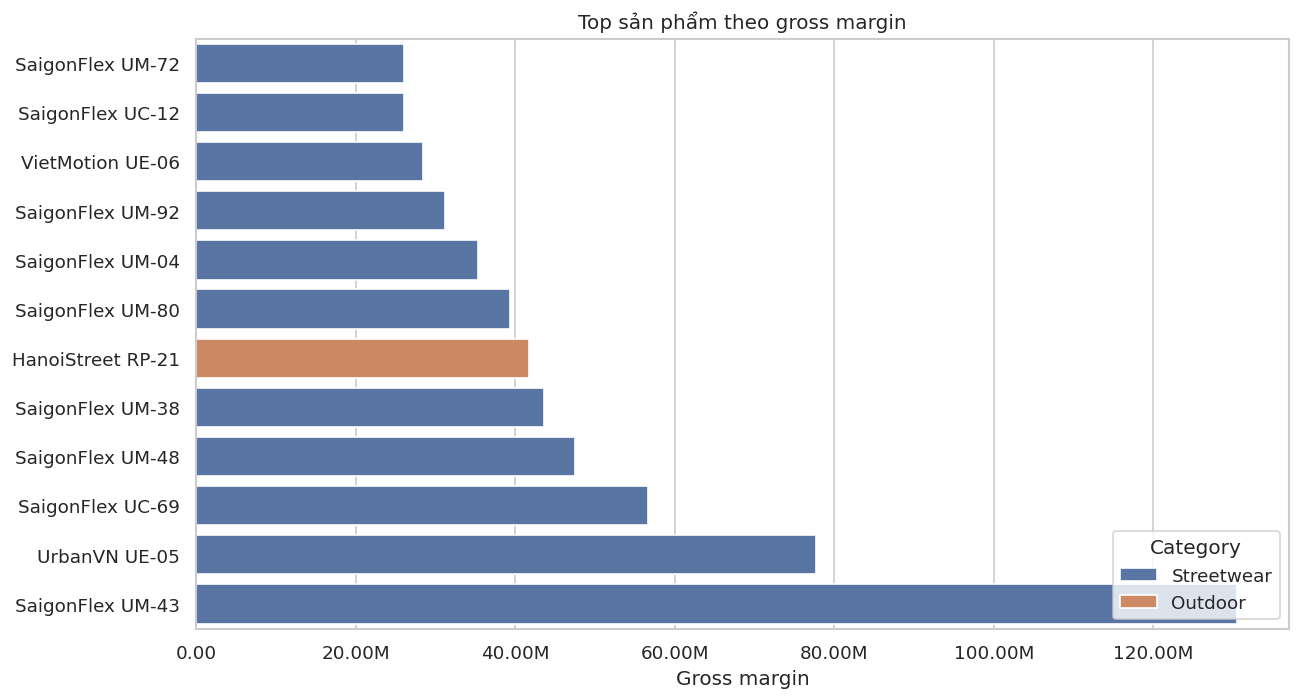

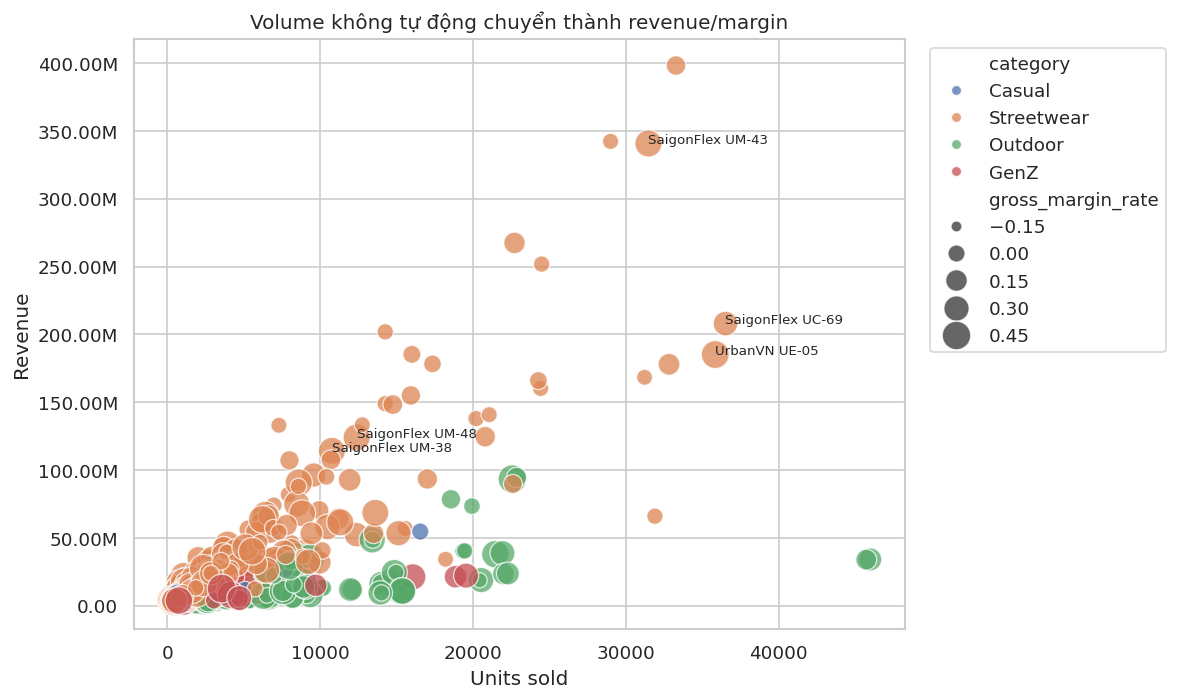

PosixPath('/home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm/group_job/figures/02_units_vs_revenue_margin.png')

In [7]:
plot_df = top_margin.sort_values("gross_margin")
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, y="product_name", x="gross_margin", hue="category", dodge=False)
ax.set_title("Top sản phẩm theo gross margin")
ax.set_xlabel("Gross margin")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda x, pos: fmt_money(x))
plt.legend(title="Category", loc="lower right")
savefig("01_top_products_by_margin.png")

scatter_df = product_summary.query("revenue > revenue.quantile(0.55)").copy()
scatter_df["revenue_b"] = scatter_df["revenue"] / 1e9
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=scatter_df,
    x="units",
    y="revenue",
    hue="category",
    size="gross_margin_rate",
    sizes=(30, 300),
    alpha=0.75,
)
ax.set_title("Volume không tự động chuyển thành revenue/margin")
ax.set_xlabel("Units sold")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(lambda x, pos: fmt_money(x))
for _, row in top_margin.head(5).iterrows():
    ax.text(row["units"], row["revenue"], row["product_name"], fontsize=8)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("02_units_vs_revenue_margin.png")


## 4. Thời điểm vàng: category và top product bán mạnh khi nào?


,category,month,revenue,units,gross_margin,season_index
0,GenZ,6,50.20M,"24,153",9.88M,1.7531
1,Streetwear,5,1.70B,"223,852",336.81M,1.5531
2,Casual,5,57.81M,"13,407",8.97M,1.5060
3,Outdoor,12,287.16M,"189,573",16.83M,1.3812


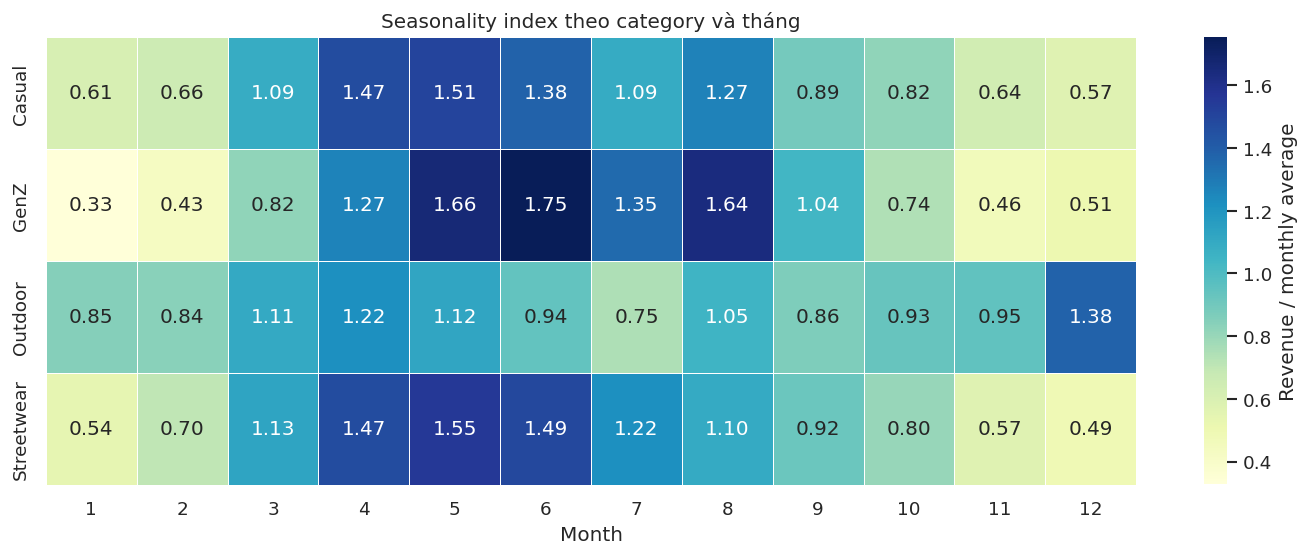

PosixPath('/home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm/group_job/figures/03_category_month_seasonality.png')

In [8]:
category_month = (
    fact.groupby(["category", "month"], as_index=False)
    .agg(revenue=("line_revenue", "sum"), units=("quantity", "sum"), gross_margin=("gross_margin", "sum"))
)
category_month["avg_month_revenue"] = category_month.groupby("category")["revenue"].transform("mean")
category_month["season_index"] = category_month["revenue"] / category_month["avg_month_revenue"]

peak_category_month = (
    category_month.loc[category_month.groupby("category")["season_index"].idxmax()]
    .sort_values("season_index", ascending=False)
    .reset_index(drop=True)
)

display(
    view_table(
        peak_category_month[["category", "month", "revenue", "units", "gross_margin", "season_index"]],
        money_cols=["revenue", "gross_margin"],
        int_cols=["units"],
    )
)

plt.figure(figsize=(12, 4.8))
heat = category_month.pivot(index="category", columns="month", values="season_index")
ax = sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.4, cbar_kws={"label": "Revenue / monthly average"})
ax.set_title("Seasonality index theo category và tháng")
ax.set_xlabel("Month")
ax.set_ylabel("")
savefig("03_category_month_seasonality.png")


,product_name,category,segment,peak_month,peak_season_index,revenue_total,gross_margin_total,promo_revenue_share,return_rate_qty,avg_rating,n_reviews
272,SaigonFlex UM-43,Streetwear,Balanced,5,1.4353,340.71M,130.46M,34.3%,3.1%,3.8946,"1,148"
1380,UrbanVN UE-05,Streetwear,Performance,5,2.0291,185.08M,77.68M,32.7%,3.0%,3.9146,"1,323"
410,SaigonFlex UC-69,Streetwear,Everyday,6,1.6501,207.93M,56.69M,31.8%,3.2%,3.9978,"1,364"
275,SaigonFlex UM-48,Streetwear,Balanced,5,1.3639,123.95M,47.50M,32.1%,3.4%,3.9454,421
268,SaigonFlex UM-38,Streetwear,Balanced,6,1.5284,114.00M,43.60M,32.9%,2.9%,3.9005,372
504,HanoiStreet RP-21,Outdoor,Activewear,10,1.4635,93.29M,41.72M,32.9%,3.4%,3.9581,835
298,SaigonFlex UM-80,Streetwear,Balanced,6,1.5337,267.39M,39.37M,29.3%,3.2%,3.9888,801
320,SaigonFlex UM-04,Streetwear,Balanced,6,1.6121,90.69M,35.33M,29.4%,3.7%,3.8105,306
308,SaigonFlex UM-92,Streetwear,Balanced,5,1.4189,398.21M,31.24M,34.3%,3.4%,3.9286,"1,190"
1545,VietMotion UE-06,Streetwear,Performance,5,2.1690,177.88M,28.40M,31.0%,3.5%,3.9486,"1,109"


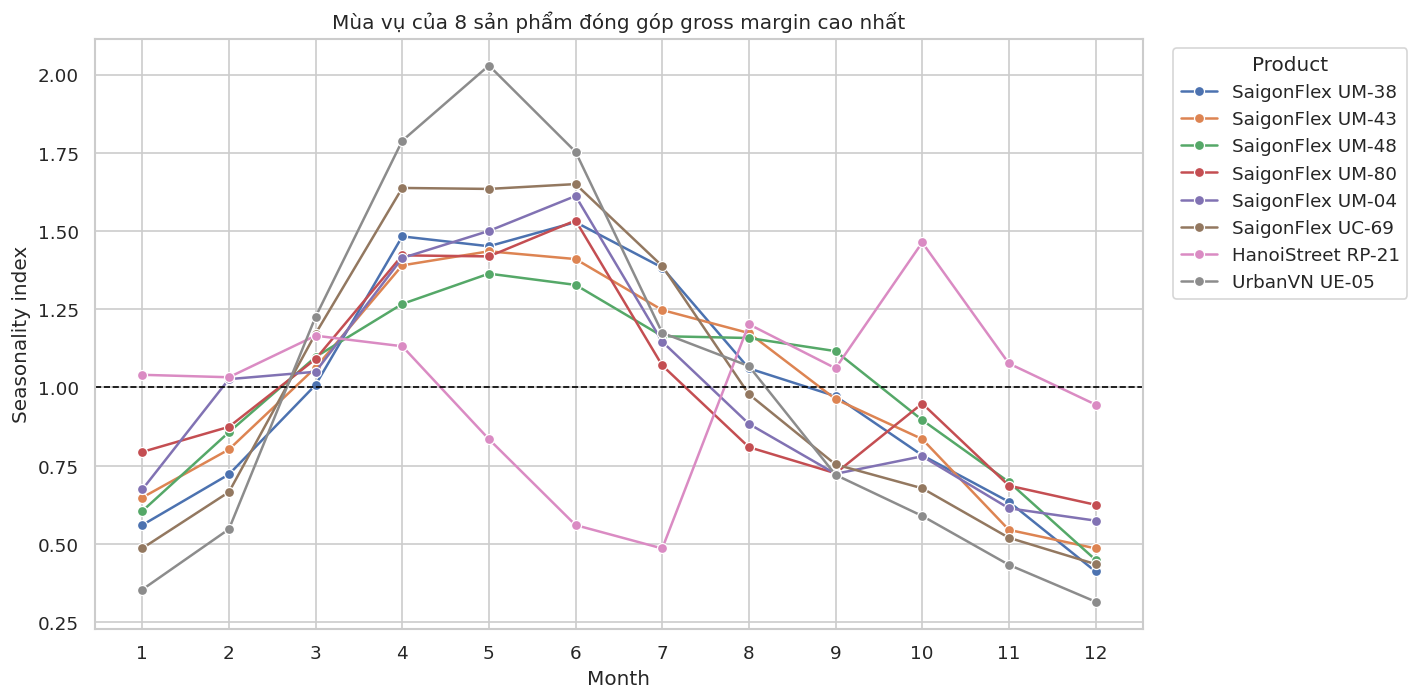

Khuyến nghị: planning promotion và tồn kho nên theo peak month của từng category/product, không dùng một lịch campaign chung cho toàn bộ danh mục.

In [9]:
product_month = (
    fact.groupby(["product_id", "product_name", "category", "segment", "month"], as_index=False)
    .agg(revenue=("line_revenue", "sum"), units=("quantity", "sum"), gross_margin=("gross_margin", "sum"))
)
product_month["avg_month_revenue"] = product_month.groupby("product_id")["revenue"].transform("mean")
product_month["season_index"] = product_month["revenue"] / product_month["avg_month_revenue"]

peak_product_month = (
    product_month.loc[product_month.groupby("product_id")["season_index"].idxmax()]
    .rename(columns={"month": "peak_month", "season_index": "peak_season_index"})
    .merge(
        product_summary[["product_id", "revenue", "gross_margin", "promo_revenue_share", "return_rate_qty", "avg_rating", "n_reviews"]],
        on="product_id",
        how="left",
        suffixes=("_peak_month", "_total"),
    )
)

top_peak_products = (
    peak_product_month.sort_values("gross_margin_total", ascending=False)
    .head(15)
    [
        [
            "product_name",
            "category",
            "segment",
            "peak_month",
            "peak_season_index",
            "revenue_total",
            "gross_margin_total",
            "promo_revenue_share",
            "return_rate_qty",
            "avg_rating",
            "n_reviews",
        ]
    ]
)

display(
    view_table(
        top_peak_products,
        money_cols=["revenue_total", "gross_margin_total"],
        pct_cols=["promo_revenue_share", "return_rate_qty"],
        int_cols=["n_reviews"],
    )
)

top_product_ids = product_summary.nlargest(8, "gross_margin")["product_id"]
season_lines = product_month[product_month["product_id"].isin(top_product_ids)].copy()
plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=season_lines, x="month", y="season_index", hue="product_name", marker="o")
ax.axhline(1, color="black", linewidth=1, linestyle="--")
ax.set_title("Mùa vụ của 8 sản phẩm đóng góp gross margin cao nhất")
ax.set_xlabel("Month")
ax.set_ylabel("Seasonality index")
ax.set_xticks(range(1, 13))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Product")
savefig("04_top_product_seasonality.png")

display(
    Markdown(
        "Khuyến nghị: planning promotion và tồn kho nên theo peak month của từng category/product, không dùng một lịch campaign chung cho toàn bộ danh mục."
    )
)
peak_product_month.to_csv(TABLE / "04_product_peak_month.csv", index=False)


## 5. Kênh bán và mức phụ thuộc promotion


,order_source,orders,units,revenue,gross_margin,promo_revenue,revenue_share,gross_margin_rate,promo_revenue_share
2,organic_search,"181,495","900,974",4.60B,635.10M,1.52B,28.0%,13.8%,33.1%
3,paid_search,"141,652","703,540",3.61B,496.92M,1.19B,22.0%,13.8%,33.1%
5,social_media,"129,710","643,456",3.29B,453.26M,1.08B,20.0%,13.8%,32.8%
1,email_campaign,"77,572","386,696",1.97B,274.45M,654.20M,12.0%,13.9%,33.2%
4,referral,"64,565","321,022",1.64B,223.85M,543.28M,10.0%,13.6%,33.1%
0,direct,"51,951","257,455",1.33B,183.43M,442.90M,8.1%,13.8%,33.4%


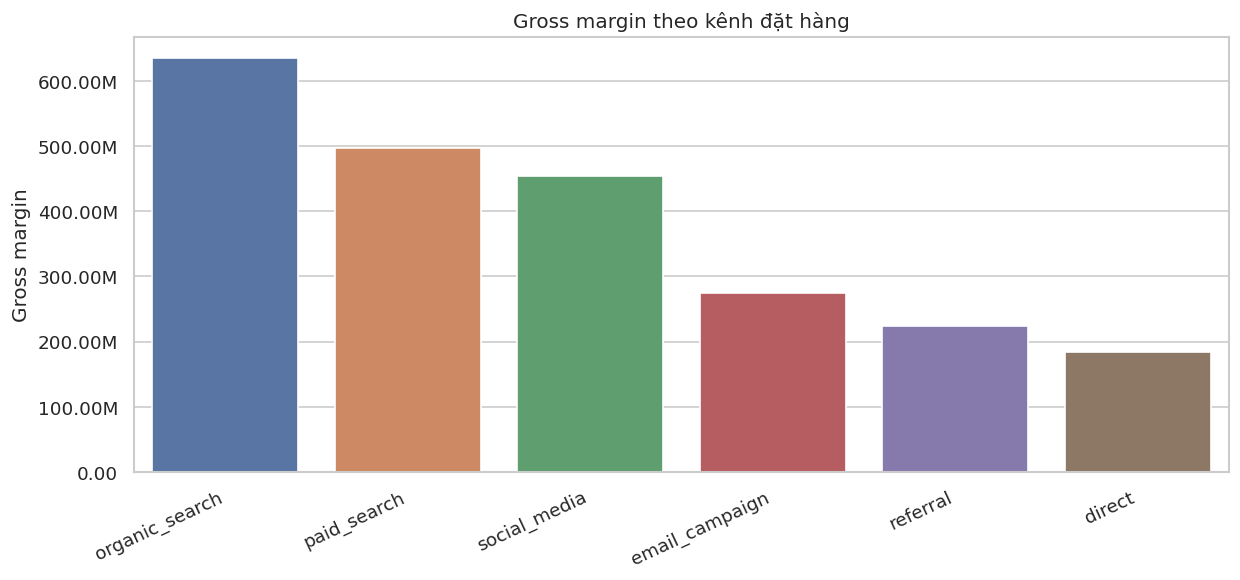

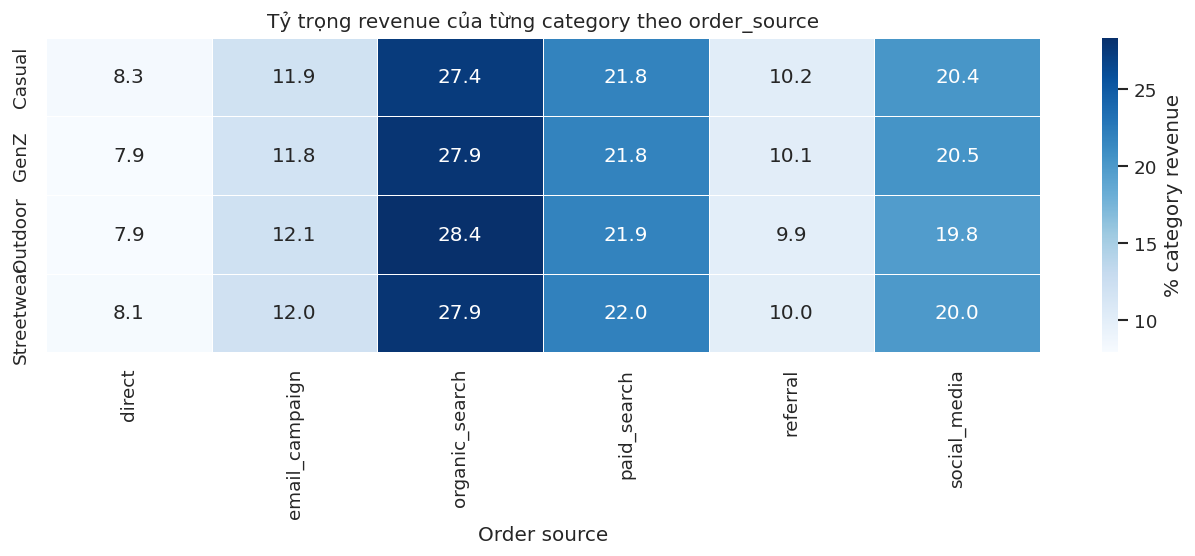

In [10]:
source_summary = (
    fact.groupby("order_source", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        units=("quantity", "sum"),
        revenue=("line_revenue", "sum"),
        gross_margin=("gross_margin", "sum"),
        promo_revenue=("promo_revenue", "sum"),
    )
)
source_summary["revenue_share"] = source_summary["revenue"] / source_summary["revenue"].sum()
source_summary["gross_margin_rate"] = source_summary["gross_margin"] / source_summary["revenue"]
source_summary["promo_revenue_share"] = source_summary["promo_revenue"] / source_summary["revenue"]
source_summary = source_summary.sort_values("gross_margin", ascending=False)

display(
    view_table(
        source_summary,
        money_cols=["revenue", "gross_margin", "promo_revenue"],
        pct_cols=["revenue_share", "gross_margin_rate", "promo_revenue_share"],
        int_cols=["orders", "units"],
    )
)

plt.figure(figsize=(10.5, 5))
ax = sns.barplot(data=source_summary, x="order_source", y="gross_margin", hue="order_source", dodge=False)
ax.set_title("Gross margin theo kênh đặt hàng")
ax.set_xlabel("")
ax.set_ylabel("Gross margin")
ax.yaxis.set_major_formatter(lambda x, pos: fmt_money(x))
plt.xticks(rotation=25, ha="right")
plt.legend([], [], frameon=False)
savefig("05_margin_by_order_source.png")

source_category = (
    fact.groupby(["category", "order_source"], as_index=False)
    .agg(revenue=("line_revenue", "sum"))
)
source_category["category_revenue_share"] = source_category["revenue"] / source_category.groupby("category")["revenue"].transform("sum")
source_pivot = source_category.pivot(index="category", columns="order_source", values="category_revenue_share").fillna(0)
plt.figure(figsize=(11, 4.8))
ax = sns.heatmap(source_pivot * 100, annot=True, fmt=".1f", cmap="Blues", linewidths=0.4, cbar_kws={"label": "% category revenue"})
ax.set_title("Tỷ trọng revenue của từng category theo order_source")
ax.set_xlabel("Order source")
ax.set_ylabel("")
savefig("06_category_source_mix.png")
source_summary.to_csv(TABLE / "05_order_source_summary.csv", index=False)


### Sản phẩm phụ thuộc promotion cao trong nhóm doanh thu/volume lớn

,product_name,category,segment,units,revenue,gross_margin,gross_margin_rate,promo_revenue_share,discount_rate,return_rate_qty
545,HanoiStreet RP-82,Outdoor,Activewear,"20,426",18.65M,-1.01M,-5.4%,51.0%,8.2%,3.4%
544,HanoiStreet RP-81,Outdoor,Activewear,"20,531",18.77M,5.56M,29.6%,50.7%,8.1%,3.0%
534,HanoiStreet RP-69,Outdoor,Activewear,"13,984",16.14M,4.32M,26.8%,49.3%,7.9%,4.1%
535,HanoiStreet RP-70,Outdoor,Activewear,"14,019",16.19M,1.25M,7.7%,49.3%,7.9%,3.7%
542,HanoiStreet RP-79,Outdoor,Activewear,"45,986",34.00M,7.10M,20.9%,47.0%,7.4%,3.4%
1505,VietMotion RP-21,Outdoor,Activewear,"15,349",10.75M,3.94M,36.7%,46.9%,7.4%,3.7%
543,HanoiStreet RP-80,Outdoor,Activewear,"45,726",33.82M,4.13M,12.2%,46.9%,7.4%,3.8%
1506,VietMotion RP-22,Outdoor,Activewear,"15,373",10.77M,3.94M,36.5%,46.2%,7.3%,3.5%
531,HanoiStreet RP-66,Outdoor,Activewear,"14,597",19.72M,2.58M,13.1%,45.6%,7.2%,3.5%
530,HanoiStreet RP-65,Outdoor,Activewear,"14,508",19.58M,-779.20K,-4.0%,45.6%,7.2%,3.4%


### Sản phẩm bán tốt không quá phụ thuộc promotion

,product_name,category,segment,units,revenue,gross_margin,gross_margin_rate,promo_revenue_share,return_rate_qty
674,MekongStyle UC-12,Streetwear,Everyday,651,8.08M,1.60M,19.9%,16.6%,4.3%
476,SaigonFlex UC-48,Streetwear,Everyday,"1,190",11.82M,4.36M,36.9%,19.9%,3.2%
435,SaigonFlex UC-99,Streetwear,Everyday,"1,099",11.13M,4.53M,40.7%,20.1%,2.9%
328,SaigonFlex UM-13,Streetwear,Balanced,"1,032",11.21M,3.89M,34.7%,20.2%,2.6%
537,HanoiStreet RP-74,Outdoor,Activewear,"15,595",10.55M,477.35K,4.5%,20.3%,3.4%
536,HanoiStreet RP-73,Outdoor,Activewear,"15,251",10.31M,3.58M,34.7%,20.7%,3.5%
57,DragonWear UM-21,Streetwear,Balanced,853,8.71M,231.65K,2.7%,20.8%,3.6%
385,SaigonFlex UC-38,Streetwear,Everyday,"2,532",8.91M,1.78M,20.0%,22.4%,3.8%
516,HanoiStreet RP-45,Outdoor,Activewear,"9,335",7.98M,2.69M,33.7%,22.7%,3.5%
421,SaigonFlex UC-82,Streetwear,Everyday,"1,469",13.92M,4.10M,29.5%,24.0%,5.2%


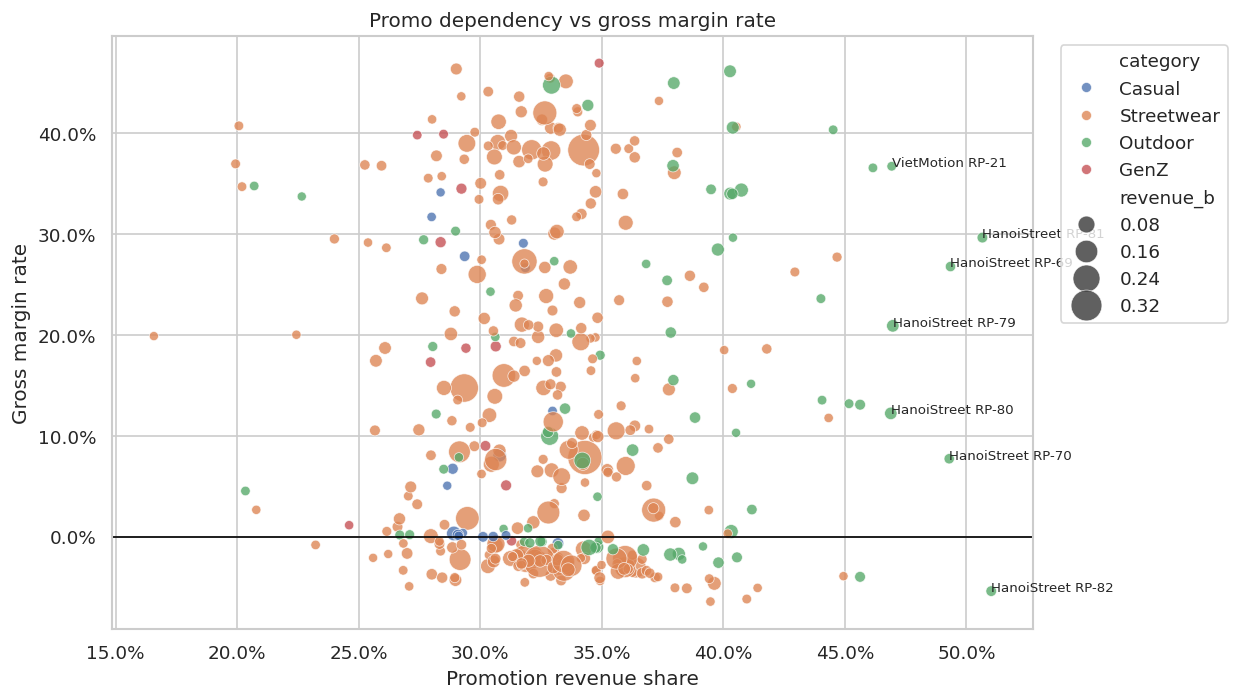


        **Insight.** Có `38.7%` dòng item dùng promotion, đóng góp `33.1%` revenue.
        Nhóm promo-dependent cần được kiểm tra margin trước khi scale: sản phẩm có promo share cao nhưng margin thấp/âm nên dùng promotion để xả tồn hoặc acquisition, không nên mặc định là growth engine.
        

### Outdoor, HanoiStreet, promotion và tồn kho

,brand,products,units,revenue,gross_margin,promo_revenue,avg_days_supply,avg_sell_through,avg_overstock_rate,gross_margin_rate,promo_revenue_share
1,HanoiStreet,73,"530,071",1.04B,216.19M,"390,787,875.0500","1,921.0868",12.4%,78.4%,20.7%,37.5%
7,VietMotion,43,"305,380",596.77M,76.52M,"214,898,853.7200","1,499.7653",11.6%,80.4%,12.8%,36.0%
6,VietMode,237,"98,283",355.39M,57.76M,"121,202,146.0100",208.0228,22.7%,45.5%,16.3%,34.1%
2,MekongFit,61,"150,317",329.53M,41.44M,"112,441,398.4000",576.0595,16.7%,66.0%,12.6%,34.1%
5,UrbanVN,48,"83,982",160.62M,15.41M,"62,971,329.6500",688.6476,14.9%,73.5%,9.6%,39.2%
3,SaigonCore,10,893,4.17M,596.33K,"1,589,331.2800",130.4152,23.2%,30.4%,14.3%,38.2%
0,DragonWear,20,886,3.72M,362.97K,"1,352,497.1900",91.6715,26.4%,10.3%,9.8%,36.3%
4,SaigonFlex,4,188,2.72M,246.53K,"427,425.8100",113.3518,26.4%,38.1%,9.0%,15.7%


### HanoiStreet Outdoor: sản phẩm yếu nhất theo gross margin

,product_name,units,revenue,gross_margin,gross_margin_rate,promo_revenue_share,avg_days_supply,avg_sell_through,overstock_rate
79,HanoiStreet RP-82,"20,426",18.65M,-1.01M,-5.4%,51.0%,"1,573.2927",9.8%,88.2%
64,HanoiStreet RP-65,"14,508",19.58M,-779.20K,-4.0%,45.6%,"1,075.3577",12.0%,82.9%
55,HanoiStreet RP-50,"19,451",40.32M,-713.13K,-1.8%,37.8%,"2,339.5303",7.2%,93.4%
54,HanoiStreet RP-49,"19,343",40.12M,-683.64K,-1.7%,38.2%,"2,295.1443",7.2%,93.4%
46,HanoiStreet RP-33,"1,969",4.85M,-97.84K,-2.0%,37.9%,"1,891.2020",5.8%,96.0%
27,HanoiStreet RP-04,"3,064",5.36M,-44.12K,-0.8%,33.1%,"1,965.0455",5.6%,100.0%
95,HanoiStreet RS-17,111,360.00K,-5.31K,-1.5%,45.5%,159.6000,17.1%,80.0%
93,HanoiStreet RS-15,20,58.86K,-979.97,-1.7%,34.8%,90.0000,25.0%,0.0%
74,HanoiStreet RP-77,"1,619",4.10M,-861.17,-0.0%,36.2%,841.8476,10.8%,88.1%
34,HanoiStreet RP-15,12,8.60K,422.66,4.9%,51.7%,90.0000,25.0%,0.0%


...

,product_name,category,segment,units,revenue,gross_margin,gross_margin_rate,promo_unit_share,promo_revenue_share,avg_days_supply,avg_sell_through,overstock_rate


### Review/return có giải thích được gross margin âm không?

,review_title,share
0,Highly recommend,10.2%
1,Very satisfied,10.1%
2,Great quality,10.0%
3,Excellent product!,9.8%
4,Happy with purchase,8.0%
5,Good overall,7.9%
6,Solid choice,7.9%
7,Works well,7.9%


,return_reason,share
0,wrong_size,34.9%
1,defective,19.9%
2,changed_mind,17.8%
3,not_as_described,17.8%
4,late_delivery,9.5%



        **Giải thích.** Review title trong dữ liệu khá generic; rating trung bình của sản phẩm lỗ là `3.94`, gần như bằng nhóm không lỗ `3.94`.
        Vì vậy review text/rating **không đủ** để giải thích lợi nhuận âm. Return reason hữu ích hơn: trong nhóm sản phẩm lỗ, các lý do lớn nhất là `wrong_size` (`34.9%`), `defective` (`19.9%`) và `changed_mind` (`17.8%`).
        Với sản phẩm vừa promo-heavy vừa lỗ, dữ liệu ủng hộ các giả thuyết: xả tồn nếu overstock cao, sửa sizing/quality nếu return reason nghiêng về wrong_size/defective, hoặc dùng làm acquisition nếu khách quay lại mua có profit. Phần acquisition cần kiểm tra ở cấp customer trong cell promo channel bên dưới; dataset không có mục tiêu campaign hay danh sách người được target nên không thể khẳng định ý định kinh doanh ban đầu.
        

In [11]:
min_revenue = product_summary["revenue"].quantile(0.75)
min_units = product_summary["units"].quantile(0.75)

promo_dependent = (
    product_summary.query("revenue >= @min_revenue and units >= @min_units")
    .sort_values(["promo_revenue_share", "revenue"], ascending=False)
    .head(15)
)

organic_winners = (
    product_summary.query("revenue >= @min_revenue and gross_margin_rate > 0")
    .sort_values(["promo_revenue_share", "gross_margin"], ascending=[True, False])
    .head(12)
)

display(Markdown("### Sản phẩm phụ thuộc promotion cao trong nhóm doanh thu/volume lớn"))
display(
    view_table(
        promo_dependent[
            [
                "product_name",
                "category",
                "segment",
                "units",
                "revenue",
                "gross_margin",
                "gross_margin_rate",
                "promo_revenue_share",
                "discount_rate",
                "return_rate_qty",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_revenue_share", "discount_rate", "return_rate_qty"],
        int_cols=["units"],
    )
)

display(Markdown("### Sản phẩm bán tốt không quá phụ thuộc promotion"))
display(
    view_table(
        organic_winners[
            [
                "product_name",
                "category",
                "segment",
                "units",
                "revenue",
                "gross_margin",
                "gross_margin_rate",
                "promo_revenue_share",
                "return_rate_qty",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_revenue_share", "return_rate_qty"],
        int_cols=["units"],
    )
)

plot_df = product_summary.query("revenue >= @min_revenue").copy()
plot_df["revenue_b"] = plot_df["revenue"] / 1e9
plt.figure(figsize=(10.5, 6))
ax = sns.scatterplot(
    data=plot_df,
    x="promo_revenue_share",
    y="gross_margin_rate",
    hue="category",
    size="revenue_b",
    sizes=(30, 420),
    alpha=0.78,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Promo dependency vs gross margin rate")
ax.set_xlabel("Promotion revenue share")
ax.set_ylabel("Gross margin rate")
ax.xaxis.set_major_formatter(lambda x, pos: fmt_pct(x))
ax.yaxis.set_major_formatter(lambda y, pos: fmt_pct(y))
for _, row in promo_dependent.head(7).iterrows():
    ax.text(row["promo_revenue_share"], row["gross_margin_rate"], row["product_name"], fontsize=8)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("07_promo_dependency_margin.png")

display(
    Markdown(
        f'''
        **Insight.** Có `{fmt_pct(fact['promo_used'].mean())}` dòng item dùng promotion, đóng góp `{fmt_pct(fact['promo_revenue'].sum() / fact['line_revenue'].sum())}` revenue.
        Nhóm promo-dependent cần được kiểm tra margin trước khi scale: sản phẩm có promo share cao nhưng margin thấp/âm nên dùng promotion để xả tồn hoặc acquisition, không nên mặc định là growth engine.
        '''
    )
)
promo_dependent.to_csv(TABLE / "06_promo_dependent_products.csv", index=False)
organic_winners.to_csv(TABLE / "07_organic_winner_products.csv", index=False)



outdoor_products = product_summary.query("category == 'Outdoor'").merge(
    inventory_product_profile[
        [
            "product_id",
            "avg_stock_on_hand",
            "avg_days_supply",
            "avg_sell_through",
            "overstock_rate",
            "overstock_score",
        ]
    ],
    on="product_id",
    how="left",
)
outdoor_products["brand"] = outdoor_products["product_name"].str.extract(r"^([^ ]+)")
outdoor_brand_summary = (
    outdoor_products.groupby("brand", as_index=False)
    .agg(
        products=("product_id", "nunique"),
        units=("units", "sum"),
        revenue=("revenue", "sum"),
        gross_margin=("gross_margin", "sum"),
        promo_revenue=("promo_revenue", "sum"),
        avg_days_supply=("avg_days_supply", "mean"),
        avg_sell_through=("avg_sell_through", "mean"),
        avg_overstock_rate=("overstock_rate", "mean"),
    )
)
outdoor_brand_summary["gross_margin_rate"] = outdoor_brand_summary["gross_margin"] / outdoor_brand_summary["revenue"]
outdoor_brand_summary["promo_revenue_share"] = outdoor_brand_summary["promo_revenue"] / outdoor_brand_summary["revenue"]
outdoor_brand_summary = outdoor_brand_summary.sort_values("gross_margin", ascending=False)

hanoi_outdoor = outdoor_products.query("brand == 'HanoiStreet'")
non_hanoi_outdoor = outdoor_products.query("brand != 'HanoiStreet'")
weak_hanoi_outdoor = hanoi_outdoor.sort_values("gross_margin").head(10)

promo_loss_products = (
    product_summary.query("gross_margin < 0 and promo_unit_share >= 0.80 and units >= @min_units")
    .merge(
        inventory_product_profile[
            ["product_id", "avg_days_supply", "avg_sell_through", "overstock_rate", "overstock_score"]
        ],
        on="product_id",
        how="left",
    )
    .sort_values("gross_margin")
)

negative_margin_reviews = reviews.merge(
    product_summary[["product_id", "gross_margin", "gross_margin_rate", "promo_revenue_share", "return_rate_qty", "units"]],
    on="product_id",
    how="left",
)
negative_margin_reviews = negative_margin_reviews.query("gross_margin < 0")
review_title_loss = (
    negative_margin_reviews["review_title"].value_counts(normalize=True).rename_axis("review_title").reset_index(name="share")
)
negative_margin_returns = returns.merge(
    product_summary[["product_id", "gross_margin"]], on="product_id", how="left"
).query("gross_margin < 0")
return_reason_loss = (
    negative_margin_returns["return_reason"].value_counts(normalize=True).rename_axis("return_reason").reset_index(name="share")
)

hanoi_gmr = hanoi_outdoor["gross_margin"].sum() / hanoi_outdoor["revenue"].sum()
non_hanoi_gmr = non_hanoi_outdoor["gross_margin"].sum() / non_hanoi_outdoor["revenue"].sum()
hanoi_promo_share = hanoi_outdoor["promo_revenue"].sum() / hanoi_outdoor["revenue"].sum()
non_hanoi_promo_share = non_hanoi_outdoor["promo_revenue"].sum() / non_hanoi_outdoor["revenue"].sum()

annually_even_outdoor = product_month.query("category == 'Outdoor'").groupby("month")["revenue"].sum()
outdoor_peak_to_avg = annually_even_outdoor.max() / annually_even_outdoor.mean()

negative_rating_avg = negative_margin_reviews["rating"].mean()
positive_rating_avg = reviews.merge(product_summary[["product_id", "gross_margin"]], on="product_id", how="left").query("gross_margin >= 0")["rating"].mean()

display(Markdown("### Outdoor, HanoiStreet, promotion và tồn kho"))
display(
    view_table(
        outdoor_brand_summary,
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_revenue_share", "avg_sell_through", "avg_overstock_rate"],
        int_cols=["products", "units"],
    )
)
display(Markdown("### HanoiStreet Outdoor: sản phẩm yếu nhất theo gross margin"))
display(
    view_table(
        weak_hanoi_outdoor[
            [
                "product_name",
                "units",
                "revenue",
                "gross_margin",
                "gross_margin_rate",
                "promo_revenue_share",
                "avg_days_supply",
                "avg_sell_through",
                "overstock_rate",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_revenue_share", "avg_sell_through", "overstock_rate"],
        int_cols=["units"],
    )
)

display(
    Markdown(
        f'''
        **Giải thích.** Outdoor đúng là bán khá đều: peak month chỉ bằng `{outdoor_peak_to_avg:.2f}x` tháng trung bình.
        HanoiStreet Outdoor không phải "bán không tốt" nếu nhìn tổng thể: gross margin rate `{fmt_pct(hanoi_gmr)}` cao hơn nhóm Outdoor còn lại `{fmt_pct(non_hanoi_gmr)}` và units cũng lớn.
        Vấn đề nằm ở **inventory quality**: HanoiStreet có days of supply trung bình `{hanoi_outdoor['avg_days_supply'].mean():.1f}` ngày, sell-through `{fmt_pct(hanoi_outdoor['avg_sell_through'].mean())}`, overstock rate `{fmt_pct(hanoi_outdoor['overstock_rate'].mean())}`; cao hơn đáng kể so với Outdoor còn lại.
        Vì vậy câu chuyện hợp lý hơn là: Outdoor/HanoiStreet có demand nền, nhưng một số SKU bị tồn nặng và phải dùng promotion mạnh; không nên kết luận cả brand yếu.
        '''
    )
)

display(Markdown("### Sản phẩm gần như chỉ bán bằng promotion nhưng vẫn lỗ"))
display(
    view_table(
        promo_loss_products.head(12)[
            [
                "product_name",
                "category",
                "segment",
                "units",
                "revenue",
                "gross_margin",
                "gross_margin_rate",
                "promo_unit_share",
                "promo_revenue_share",
                "avg_days_supply",
                "avg_sell_through",
                "overstock_rate",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["gross_margin_rate", "promo_unit_share", "promo_revenue_share", "avg_sell_through", "overstock_rate"],
        int_cols=["units"],
    )
)

display(Markdown("### Review/return có giải thích được gross margin âm không?"))
display(view_table(review_title_loss.head(8), pct_cols=["share"]))
display(view_table(return_reason_loss.head(8), pct_cols=["share"]))

display(
    Markdown(
        f'''
        **Giải thích.** Review title trong dữ liệu khá generic; rating trung bình của sản phẩm lỗ là `{negative_rating_avg:.2f}`, gần như bằng nhóm không lỗ `{positive_rating_avg:.2f}`.
        Vì vậy review text/rating **không đủ** để giải thích lợi nhuận âm. Return reason hữu ích hơn: trong nhóm sản phẩm lỗ, các lý do lớn nhất là `{return_reason_loss.iloc[0]['return_reason']}` (`{fmt_pct(return_reason_loss.iloc[0]['share'])}`), `{return_reason_loss.iloc[1]['return_reason']}` (`{fmt_pct(return_reason_loss.iloc[1]['share'])}`) và `{return_reason_loss.iloc[2]['return_reason']}` (`{fmt_pct(return_reason_loss.iloc[2]['share'])}`).
        Với sản phẩm vừa promo-heavy vừa lỗ, dữ liệu ủng hộ các giả thuyết: xả tồn nếu overstock cao, sửa sizing/quality nếu return reason nghiêng về wrong_size/defective, hoặc dùng làm acquisition nếu khách quay lại mua có profit. Phần acquisition cần kiểm tra ở cấp customer trong cell promo channel bên dưới; dataset không có mục tiêu campaign hay danh sách người được target nên không thể khẳng định ý định kinh doanh ban đầu.
        '''
    )
)

outdoor_brand_summary.to_csv(TABLE / "17_outdoor_brand_summary.csv", index=False)
weak_hanoi_outdoor.to_csv(TABLE / "18_hanoistreet_outdoor_weak_products.csv", index=False)
promo_loss_products.to_csv(TABLE / "19_promo_loss_products.csv", index=False)
review_title_loss.to_csv(TABLE / "20_negative_margin_review_title_share.csv", index=False)
return_reason_loss.to_csv(TABLE / "21_negative_margin_return_reason_share.csv", index=False)


In [ ]:
# TODO: Sản phẩm mang lại doanh thu, cần biết promotion áp dụng là gì, số lượng lưu trữ hàng và tỷ lệ bán ra trong tháng của sản phầm thế nào, liên quan với cả shipment fee? Tương tự với sản phẩm lỗ
# => Trả lời cho nhập hàng

In [12]:
promo_fact = fact[fact["promo_id"].notna()].merge(
    promotions[["promo_id", "promo_name", "promo_type", "discount_value", "promo_channel", "applicable_category"]],
    on="promo_id",
    how="left",
)
promo_channel_summary = (
    promo_fact.groupby("promo_channel", dropna=False, as_index=False)
    .agg(
        promoted_lines=("line_id", "size"),
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum"),
        revenue=("line_revenue", "sum"),
        gross_margin=("gross_margin", "sum"),
        discount_amount=("discount_amount", "sum"),
        gross_before_discount=("line_gross_before_discount", "sum"),
        avg_discount=("discount_amount", "mean"),
        avg_discount_value=("discount_value", "mean"),
    )
    .sort_values("gross_margin", ascending=False)
)
promo_channel_summary["gross_margin_rate"] = promo_channel_summary["gross_margin"] / promo_channel_summary["revenue"]
promo_channel_summary["discount_rate"] = promo_channel_summary["discount_amount"] / promo_channel_summary["gross_before_discount"]
promo_channel_summary["profit_per_customer"] = promo_channel_summary["gross_margin"] / promo_channel_summary["customers"]

display(
    view_table(
        promo_channel_summary[
            [
                "promo_channel",
                "promoted_lines",
                "customers",
                "orders",
                "units",
                "revenue",
                "gross_margin",
                "gross_margin_rate",
                "discount_rate",
                "avg_discount_value",
                "profit_per_customer",
            ]
        ],
        money_cols=["revenue", "gross_margin", "avg_discount", "profit_per_customer"],
        pct_cols=["gross_margin_rate", "discount_rate"],
        int_cols=["promoted_lines", "customers", "orders", "units"],
    )
)

promoted_orders = (
    promo_fact.groupby(["customer_id", "order_id", "order_date", "promo_channel"], as_index=False)
    .agg(first_promo_margin=("gross_margin", "sum"), first_promo_revenue=("line_revenue", "sum"))
)
first_exposure = (
    promoted_orders.sort_values("order_date")
    .drop_duplicates(["customer_id", "promo_channel"])
    .rename(columns={"order_date": "exposure_date", "order_id": "exposure_order_id"})
)
all_orders = (
    fact.groupby(["customer_id", "order_id", "order_date"], as_index=False)
    .agg(order_margin=("gross_margin", "sum"), order_revenue=("line_revenue", "sum"))
)
next_orders_join = first_exposure[
    ["customer_id", "promo_channel", "exposure_date", "exposure_order_id", "first_promo_margin"]
].merge(all_orders, on="customer_id", how="left")
next_orders_90d = next_orders_join[
    (next_orders_join["order_date"] > next_orders_join["exposure_date"])
    & (next_orders_join["order_date"] <= next_orders_join["exposure_date"] + pd.Timedelta(days=90))
]
next_orders_90d = (
    next_orders_90d.groupby(["customer_id", "promo_channel", "exposure_date"], as_index=False)
    .agg(next_orders_90d=("order_id", "nunique"), next_margin_90d=("order_margin", "sum"))
)
promo_repeat_90d = first_exposure.merge(
    next_orders_90d, on=["customer_id", "promo_channel", "exposure_date"], how="left"
)
promo_repeat_90d[["next_orders_90d", "next_margin_90d"]] = promo_repeat_90d[
    ["next_orders_90d", "next_margin_90d"]
].fillna(0)
promo_repeat_90d["repeat_90d"] = promo_repeat_90d["next_orders_90d"] > 0

promo_channel_repeat = (
    promo_repeat_90d.groupby("promo_channel", as_index=False)
    .agg(
        exposed_customers=("customer_id", "nunique"),
        repeat_rate_90d=("repeat_90d", "mean"),
        avg_next_orders_90d=("next_orders_90d", "mean"),
        avg_next_margin_90d=("next_margin_90d", "mean"),
        total_next_margin_90d=("next_margin_90d", "sum"),
        first_promo_margin=("first_promo_margin", "sum"),
    )
    .sort_values("repeat_rate_90d", ascending=False)
)

email_repeat = promo_channel_repeat.query("promo_channel == 'email'").iloc[0]
email_repeat_per_10 = email_repeat["repeat_rate_90d"] * 10
email_next_margin_per_10 = email_repeat["avg_next_margin_90d"] * 10
lowest_margin_channel = promo_channel_summary.sort_values("gross_margin_rate").iloc[0]
highest_margin_channel = promo_channel_summary.sort_values("gross_margin_rate", ascending=False).iloc[0]

display(Markdown("### Repeat purchase sau lần đầu dùng promo channel"))
display(
    view_table(
        promo_channel_repeat,
        money_cols=["avg_next_margin_90d", "total_next_margin_90d", "first_promo_margin"],
        pct_cols=["repeat_rate_90d"],
        int_cols=["exposed_customers"],
    )
)

display(
    Markdown(
        f'''
        **Giải thích.** Chênh lệch gross margin theo promo channel chủ yếu đến từ mix discount và mix sản phẩm/khách hàng sau khi campaign đã tạo đơn.
        `{lowest_margin_channel['promo_channel']}` thấp nhất với gross margin rate `{fmt_pct(lowest_margin_channel['gross_margin_rate'])}` và discount rate `{fmt_pct(lowest_margin_channel['discount_rate'])}`, trong khi `{highest_margin_channel['promo_channel']}` cao nhất với gross margin rate `{fmt_pct(highest_margin_channel['gross_margin_rate'])}`.
        Với email, trong nhóm khách **đã mua bằng email promo**, cứ 10 khách thì khoảng `{email_repeat_per_10:.1f}` khách có đơn tiếp theo trong 90 ngày, tạo trung bình `{fmt_money(email_next_margin_per_10)}` gross margin sau đó.
        Nhưng đây là phân tích association, không phải causal impact: dataset không có danh sách người được email target nhưng không mua, nên không thể nói "email target 10 người" chắc chắn tạo profit tương ứng. Có thể nói email-promo purchasers có downstream profit tốt hơn online, và nên A/B test hoặc dùng holdout để đo incremental lift thật.
        '''
    )
)

display(
    Markdown(
        "Lưu ý: bảng `promo_channel` chỉ phản ánh các dòng có `promo_id` chính. Nếu một dòng có `promo_id_2`, revenue không được double-count cho kênh thứ hai để tránh phóng đại doanh thu."
    )
)
promo_channel_summary.to_csv(TABLE / "08_promo_channel_summary.csv", index=False)
promo_channel_repeat.to_csv(TABLE / "22_promo_channel_repeat_90d.csv", index=False)
promo_repeat_90d.to_csv(TABLE / "23_promo_customer_repeat_90d.csv", index=False)


,promo_channel,promoted_lines,customers,orders,units,revenue,gross_margin,gross_margin_rate,discount_rate,avg_discount_value,profit_per_customer
0,all_channels,"127,687","47,382","111,358","573,839",2.34B,127.22M,5.4%,13.2%,16.2445,2.68K
1,email,"41,576","25,336","37,728","186,689",900.63M,92.67M,10.3%,9.7%,10.8609,3.66K
4,social_media,"31,977","21,817","29,697","143,667",689.17M,18.79M,2.7%,15.3%,18.0000,861.43
2,in_store,"8,905","5,612","6,920","39,933",85.68M,6.48M,7.6%,13.0%,15.0000,1.15K
3,online,"66,171","35,862","62,539","297,911",1.42B,-173.15M,-12.2%,10.1%,26.1635,-4.83K


### Repeat purchase sau lần đầu dùng promo channel

,promo_channel,exposed_customers,repeat_rate_90d,avg_next_orders_90d,avg_next_margin_90d,total_next_margin_90d,first_promo_margin
2,in_store,"5,612",42.2%,0.6800,2.42K,13.59M,5.04M
1,email,"25,336",29.9%,0.4304,1.57K,39.85M,61.60M
4,social_media,"21,817",27.4%,0.3773,862.67,18.82M,13.85M
0,all_channels,"47,382",25.0%,0.3461,1.23K,58.11M,51.98M
3,online,"35,862",24.6%,0.3304,528.69,18.96M,-103.92M



        **Giải thích.** Chênh lệch gross margin theo promo channel chủ yếu đến từ mix discount và mix sản phẩm/khách hàng sau khi campaign đã tạo đơn.
        `online` thấp nhất với gross margin rate `-12.2%` và discount rate `10.1%`, trong khi `email` cao nhất với gross margin rate `10.3%`.
        Với email, trong nhóm khách **đã mua bằng email promo**, cứ 10 khách thì khoảng `3.0` khách có đơn tiếp theo trong 90 ngày, tạo trung bình `15.73K` gross margin sau đó.
        Nhưng đây là phân tích association, không phải causal impact: dataset không có danh sách người được email target nhưng không mua, nên không thể nói "email target 10 người" chắc chắn tạo profit tương ứng. Có thể nói email-promo purchasers có downstream profit tốt hơn online, và nên A/B test hoặc dùng holdout để đo incremental lift thật.
        

Lưu ý: bảng `promo_channel` chỉ phản ánh các dòng có `promo_id` chính. Nếu một dòng có `promo_id_2`, revenue không được double-count cho kênh thứ hai để tránh phóng đại doanh thu.

## 6. Return và review: sản phẩm nào làm rò rỉ doanh thu?


,return_reason,share
0,wrong_size,35.0%
1,defective,20.1%
2,not_as_described,17.6%
3,changed_mind,17.4%
4,late_delivery,10.0%


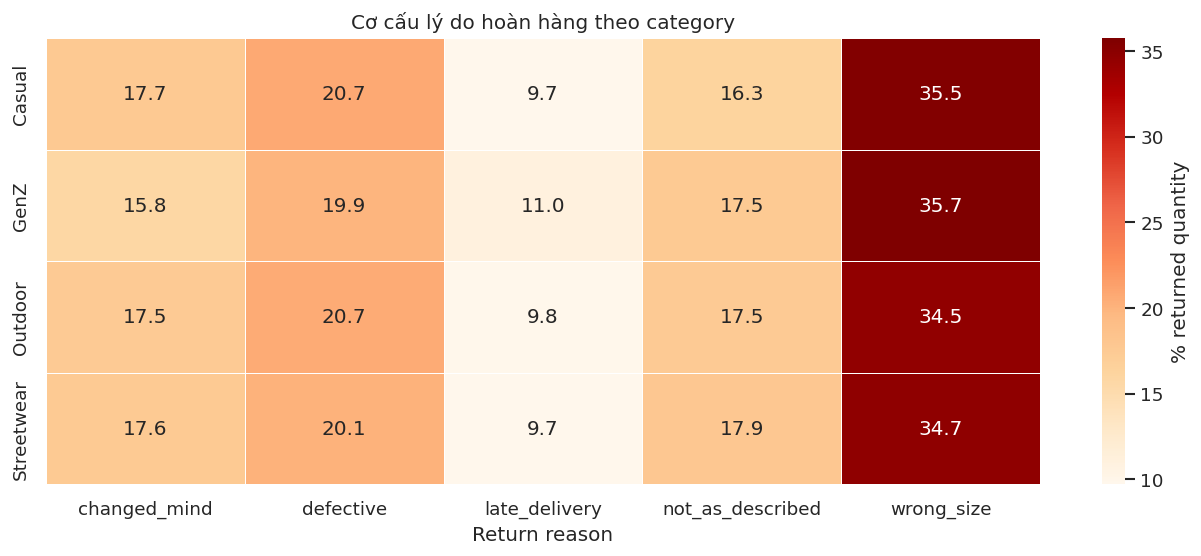

### Sản phẩm volume lớn có return/refund risk cao

,product_name,category,segment,units,revenue,gross_margin,return_rate_qty,refund_share,avg_rating,n_reviews
1322,UrbanVN RP-12,Outdoor,Activewear,"1,704",5.54M,-35.43K,6.1%,5.7%,3.9107,56
1516,VietMotion RP-38,Outdoor,Activewear,"2,023",2.11M,851.44K,5.5%,5.0%,3.8784,74
1391,UrbanVN UE-18,Streetwear,Performance,"5,863",17.83M,7.86M,5.2%,4.7%,3.9045,199
1022,VietMode RP-88,Outdoor,Activewear,"1,772",7.77M,2.78M,5.2%,4.8%,3.9483,58
1597,VietMotion YY-21,GenZ,Trendy,"4,701",5.50M,1.57M,5.0%,4.7%,3.9818,165
1232,SaigonCore YY-14,GenZ,Trendy,"2,194",6.62M,1.24M,4.9%,4.4%,3.8090,89
1401,UrbanVN UC-09,Streetwear,Everyday,"2,049",7.73M,1.67M,4.8%,4.4%,3.9101,89
398,SaigonFlex UC-54,Streetwear,Everyday,"2,164",20.49M,4.80M,4.8%,4.5%,3.9429,70
988,VietMode RP-46,Outdoor,Activewear,"1,746",8.12M,-78.38K,4.8%,4.5%,3.9649,57
611,HanoiStreet UC-08,Streetwear,Everyday,"3,426",26.22M,-602.98K,4.6%,4.2%,4.0481,104


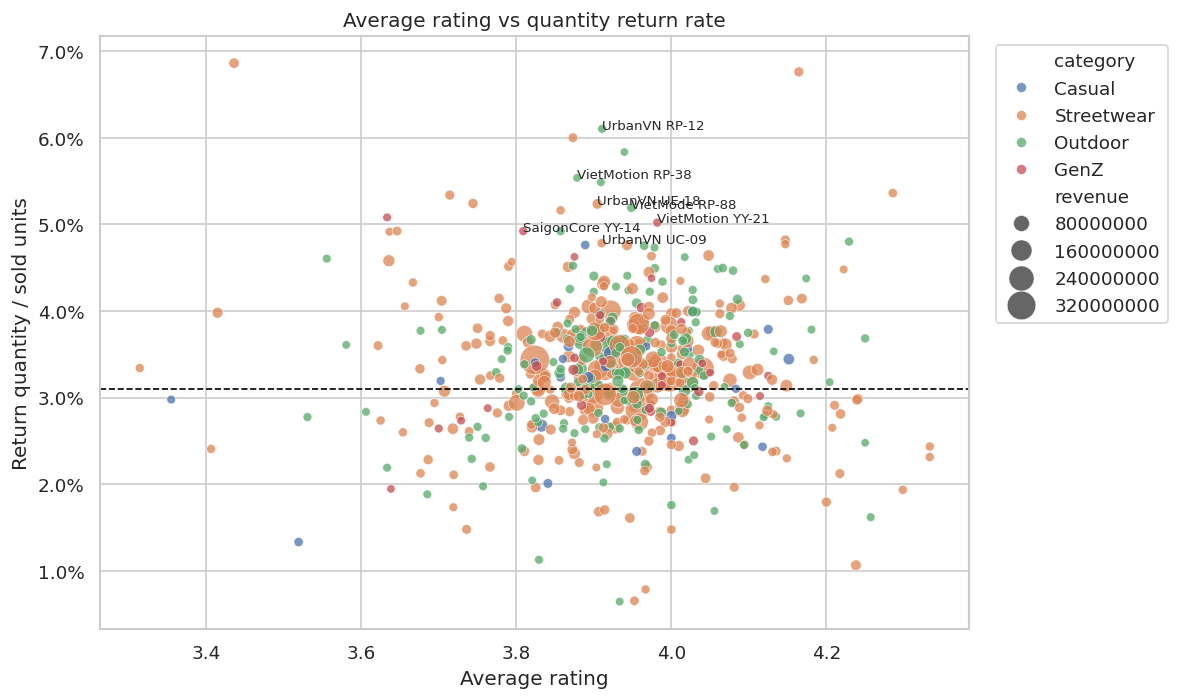


        **Insight.** Lý do hoàn hàng lớn nhất là `wrong_size` với `35.0%` số dòng return.
        Tương quan product-level giữa rating và return rate trong nhóm có đủ review là `-0.017`, nên rating không đủ thay thế return analysis.
        Nên xử lý return bằng reason cụ thể, đặc biệt size/defect/description, thay vì chỉ nhìn điểm review trung bình.
        

In [13]:
returns_with_category = returns.merge(products[["product_id", "product_name", "category", "segment"]], on="product_id", how="left")
reason_share = (
    returns_with_category["return_reason"]
    .value_counts(normalize=True)
    .rename_axis("return_reason")
    .reset_index(name="share")
)
display(view_table(reason_share, pct_cols=["share"]))

reason_category = (
    returns_with_category.groupby(["category", "return_reason"], as_index=False)
    .agg(return_qty=("return_quantity", "sum"))
)
reason_category["share_within_category"] = reason_category["return_qty"] / reason_category.groupby("category")["return_qty"].transform("sum")
reason_pivot = reason_category.pivot(index="category", columns="return_reason", values="share_within_category").fillna(0)

plt.figure(figsize=(11, 4.8))
ax = sns.heatmap(reason_pivot * 100, annot=True, fmt=".1f", cmap="OrRd", linewidths=0.4, cbar_kws={"label": "% returned quantity"})
ax.set_title("Cơ cấu lý do hoàn hàng theo category")
ax.set_xlabel("Return reason")
ax.set_ylabel("")
savefig("08_return_reason_by_category.png")

min_reviews = 30
quality_df = product_summary.query("n_reviews >= @min_reviews and units >= units.quantile(0.50)").copy()
rating_return_corr = quality_df[["avg_rating", "return_rate_qty"]].corr().iloc[0, 1]

risk_products = (
    product_summary.query("units >= @min_units and n_reviews >= @min_reviews")
    .assign(
        risk_score=lambda d: d["return_rate_qty"].fillna(0) * 0.65
        + d["refund_share"].fillna(0) * 0.25
        + (1 - d["avg_rating"].fillna(d["avg_rating"].median()) / 5) * 0.10
    )
    .sort_values(["return_rate_qty", "refund_share"], ascending=False)
    .head(15)
)

display(Markdown("### Sản phẩm volume lớn có return/refund risk cao"))
display(
    view_table(
        risk_products[
            [
                "product_name",
                "category",
                "segment",
                "units",
                "revenue",
                "gross_margin",
                "return_rate_qty",
                "refund_share",
                "avg_rating",
                "n_reviews",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["return_rate_qty", "refund_share"],
        int_cols=["units", "n_reviews"],
    )
)

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=quality_df,
    x="avg_rating",
    y="return_rate_qty",
    hue="category",
    size="revenue",
    sizes=(25, 360),
    alpha=0.75,
)
ax.axhline(product_summary["return_rate_qty"].median(), color="black", linestyle="--", linewidth=1)
ax.set_title("Average rating vs quantity return rate")
ax.set_xlabel("Average rating")
ax.set_ylabel("Return quantity / sold units")
ax.yaxis.set_major_formatter(lambda y, pos: fmt_pct(y))
for _, row in risk_products.head(7).iterrows():
    ax.text(row["avg_rating"], row["return_rate_qty"], row["product_name"], fontsize=8)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("09_rating_vs_return_rate.png")

display(
    Markdown(
        f'''
        **Insight.** Lý do hoàn hàng lớn nhất là `{reason_share.iloc[0]['return_reason']}` với `{fmt_pct(reason_share.iloc[0]['share'])}` số dòng return.
        Tương quan product-level giữa rating và return rate trong nhóm có đủ review là `{rating_return_corr:.3f}`, nên rating không đủ thay thế return analysis.
        Nên xử lý return bằng reason cụ thể, đặc biệt size/defect/description, thay vì chỉ nhìn điểm review trung bình.
        '''
    )
)
risk_products.to_csv(TABLE / "09_return_risk_products.csv", index=False)
reason_share.to_csv(TABLE / "10_return_reason_share.csv", index=False)


## 7. Khu vực nào mua từng danh mục/sản phẩm?


,category,region,units,revenue,gross_margin,category_region_share
0,Casual,West,"42,367",184.85M,21.95M,40.1%
1,GenZ,East,"75,993",161.22M,30.59M,46.9%
2,Outdoor,West,"426,190",1.01B,172.25M,40.5%
3,Streetwear,East,"868,555",6.41B,849.45M,48.8%


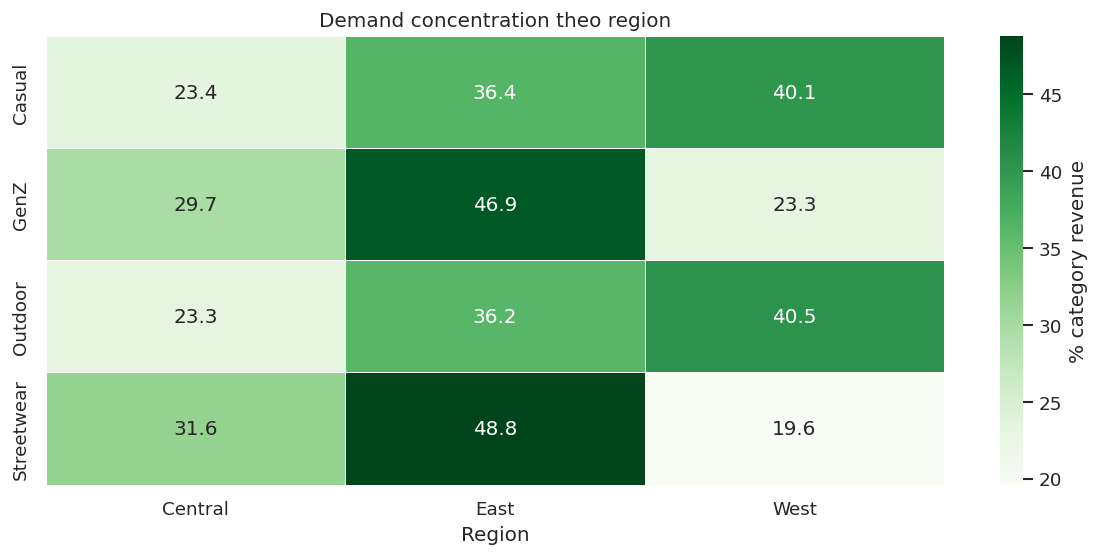

### Thành phố mạnh nhất của top product theo gross margin

,product_name,category,city,revenue,units,product_city_share,gross_margin,promo_revenue_share,return_rate_qty
1,SaigonFlex UM-43,Streetwear,Hai Phong,12.55M,"1,155",3.7%,130.46M,34.3%,3.1%
10,UrbanVN UE-05,Streetwear,Son Tay,8.04M,"1,542",4.3%,77.68M,32.7%,3.0%
7,SaigonFlex UC-69,Streetwear,Phu Ly,8.69M,"1,519",4.2%,56.69M,31.8%,3.2%
2,SaigonFlex UM-48,Streetwear,Thai Nguyen,4.85M,486,3.9%,47.50M,32.1%,3.4%
0,SaigonFlex UM-38,Streetwear,Ninh Binh,4.87M,455,4.3%,43.60M,32.9%,2.9%
9,HanoiStreet RP-21,Outdoor,Pleiku,4.16M,"1,004",4.5%,41.72M,32.9%,3.4%
4,SaigonFlex UM-80,Streetwear,Son Tay,11.79M,991,4.4%,39.37M,29.3%,3.2%
6,SaigonFlex UM-04,Streetwear,Nam Dinh,4.25M,405,4.7%,35.33M,29.4%,3.7%
5,SaigonFlex UM-92,Streetwear,Viet Tri,16.72M,"1,393",4.2%,31.24M,34.3%,3.4%
11,VietMotion UE-06,Streetwear,Nam Dinh,6.81M,"1,246",3.8%,28.40M,31.0%,3.5%


Không có tồn kho theo region, nên phần location dùng để định hướng demand/campaign. Không nên kết luận tái phân bổ kho theo vùng nếu chưa có warehouse-level stock.

In [14]:
fact_geo = fact.merge(geography[["zip", "city", "region", "district"]], on="zip", how="left")

region_category = (
    fact_geo.groupby(["category", "region"], dropna=False, as_index=False)
    .agg(units=("quantity", "sum"), revenue=("line_revenue", "sum"), gross_margin=("gross_margin", "sum"))
)
region_category["category_region_share"] = region_category["revenue"] / region_category.groupby("category")["revenue"].transform("sum")

top_region_by_category = (
    region_category.loc[region_category.groupby("category")["revenue"].idxmax()]
    .sort_values("category")
    .reset_index(drop=True)
)
display(
    view_table(
        top_region_by_category,
        money_cols=["revenue", "gross_margin"],
        pct_cols=["category_region_share"],
        int_cols=["units"],
    )
)

region_pivot = region_category.pivot(index="category", columns="region", values="category_region_share").fillna(0)
plt.figure(figsize=(10, 4.8))
ax = sns.heatmap(region_pivot * 100, annot=True, fmt=".1f", cmap="Greens", linewidths=0.4, cbar_kws={"label": "% category revenue"})
ax.set_title("Demand concentration theo region")
ax.set_xlabel("Region")
ax.set_ylabel("")
savefig("10_category_region_share.png")

city_products = (
    fact_geo.groupby(["product_id", "product_name", "category", "city"], as_index=False)
    .agg(revenue=("line_revenue", "sum"), units=("quantity", "sum"))
)
city_products["product_city_share"] = city_products["revenue"] / city_products.groupby("product_id")["revenue"].transform("sum")
top_city_for_margin_products = (
    city_products[city_products["product_id"].isin(top_margin["product_id"])]
    .sort_values(["product_id", "product_city_share"], ascending=[True, False])
    .groupby("product_id", as_index=False)
    .head(1)
    .merge(top_margin[["product_id", "gross_margin", "promo_revenue_share", "return_rate_qty"]], on="product_id", how="left")
    .sort_values("gross_margin", ascending=False)
)
display(Markdown("### Thành phố mạnh nhất của top product theo gross margin"))
display(
    view_table(
        top_city_for_margin_products[
            ["product_name", "category", "city", "revenue", "units", "product_city_share", "gross_margin", "promo_revenue_share", "return_rate_qty"]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["product_city_share", "promo_revenue_share", "return_rate_qty"],
        int_cols=["units"],
    )
)

display(
    Markdown(
        "Không có tồn kho theo region, nên phần location dùng để định hướng demand/campaign. Không nên kết luận tái phân bổ kho theo vùng nếu chưa có warehouse-level stock."
    )
)
region_category.to_csv(TABLE / "11_region_category_summary.csv", index=False)
top_city_for_margin_products.to_csv(TABLE / "12_top_product_city_focus.csv", index=False)


## 8. Tồn kho: có đủ hàng trong thời gian vàng không, và hàng nào tồn lâu?


In [15]:
inv_month = (
    inventory.groupby(["product_id", "month"], as_index=False)
    .agg(
        inv_units_sold=("units_sold", "sum"),
        avg_stock_on_hand=("stock_on_hand", "mean"),
        avg_units_received=("units_received", "mean"),
        avg_stockout_days=("stockout_days", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        avg_days_supply=("days_of_supply", "mean"),
        stockout_rate=("stockout_flag", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        reorder_rate=("reorder_flag", "mean"),
        avg_sell_through=("sell_through_rate", "mean"),
    )
)

peak_for_inventory = peak_product_month[["product_id", "product_name", "category", "segment", "peak_month", "peak_season_index", "revenue_total", "gross_margin_total"]].copy()
peak_inv = inv_month.rename(
    columns={
        "month": "peak_month",
        "avg_stockout_days": "peak_avg_stockout_days",
        "avg_fill_rate": "peak_avg_fill_rate",
        "avg_days_supply": "peak_avg_days_supply",
        "stockout_rate": "peak_stockout_rate",
        "overstock_rate": "peak_overstock_rate",
        "avg_sell_through": "peak_avg_sell_through",
        "avg_stock_on_hand": "peak_avg_stock_on_hand",
    }
)
readiness = peak_for_inventory.merge(
    peak_inv[
        [
            "product_id",
            "peak_month",
            "peak_avg_stock_on_hand",
            "peak_avg_stockout_days",
            "peak_avg_fill_rate",
            "peak_avg_days_supply",
            "peak_stockout_rate",
            "peak_overstock_rate",
            "peak_avg_sell_through",
        ]
    ],
    on=["product_id", "peak_month"],
    how="left",
)
readiness["prev_month"] = np.where(readiness["peak_month"] == 1, 12, readiness["peak_month"] - 1)
prev_inv = inv_month.rename(
    columns={
        "month": "prev_month",
        "avg_stockout_days": "prev_avg_stockout_days",
        "avg_fill_rate": "prev_avg_fill_rate",
        "avg_days_supply": "prev_avg_days_supply",
        "stockout_rate": "prev_stockout_rate",
        "overstock_rate": "prev_overstock_rate",
        "avg_sell_through": "prev_avg_sell_through",
        "avg_stock_on_hand": "prev_avg_stock_on_hand",
    }
)
readiness = readiness.merge(
    prev_inv[
        [
            "product_id",
            "prev_month",
            "prev_avg_stock_on_hand",
            "prev_avg_stockout_days",
            "prev_avg_fill_rate",
            "prev_avg_days_supply",
            "prev_stockout_rate",
            "prev_overstock_rate",
            "prev_avg_sell_through",
        ]
    ],
    on=["product_id", "prev_month"],
    how="left",
)
readiness["inventory_risk_score"] = (
    readiness["peak_avg_stockout_days"].fillna(0)
    + readiness["prev_avg_stockout_days"].fillna(0)
    + (1 - readiness["peak_avg_fill_rate"].fillna(1)) * 30
    + (1 - readiness["prev_avg_fill_rate"].fillna(1)) * 30
)

top_margin_readiness = (
    readiness[readiness["product_id"].isin(top_margin["product_id"])]
    .sort_values("gross_margin_total", ascending=False)
)
display(Markdown("### Inventory readiness của top sản phẩm theo gross margin"))
display(
    view_table(
        top_margin_readiness[
            [
                "product_name",
                "category",
                "peak_month",
                "peak_season_index",
                "gross_margin_total",
                "prev_avg_stockout_days",
                "prev_avg_fill_rate",
                "peak_avg_stockout_days",
                "peak_avg_fill_rate",
                "peak_avg_days_supply",
                "inventory_risk_score",
            ]
        ],
        money_cols=["gross_margin_total"],
        pct_cols=["prev_avg_fill_rate", "peak_avg_fill_rate"],
    )
)

high_demand_stockout = (
    readiness.query("gross_margin_total >= gross_margin_total.quantile(0.75)")
    .sort_values("inventory_risk_score", ascending=False)
    .head(15)
)
display(Markdown("### High-demand products có rủi ro stockout quanh tháng peak"))
display(
    view_table(
        high_demand_stockout[
            [
                "product_name",
                "category",
                "peak_month",
                "peak_season_index",
                "revenue_total",
                "gross_margin_total",
                "prev_avg_stockout_days",
                "peak_avg_stockout_days",
                "peak_avg_fill_rate",
                "inventory_risk_score",
            ]
        ],
        money_cols=["revenue_total", "gross_margin_total"],
        pct_cols=["peak_avg_fill_rate"],
    )
)


### Inventory readiness của top sản phẩm theo gross margin

,product_name,category,peak_month,peak_season_index,gross_margin_total,prev_avg_stockout_days,prev_avg_fill_rate,peak_avg_stockout_days,peak_avg_fill_rate,peak_avg_days_supply,inventory_risk_score
272,SaigonFlex UM-43,Streetwear,5,1.4353,130.46M,2.5714,91.4%,1.1429,96.2%,"7,647.3429",7.4283
1380,UrbanVN UE-05,Streetwear,5,2.0291,77.68M,1.1000,96.3%,0.6000,98.0%,"1,012.6700",3.3998
410,SaigonFlex UC-69,Streetwear,6,1.6501,56.69M,1.2000,96.0%,0.9000,97.0%,727.9100,4.2000
275,SaigonFlex UM-48,Streetwear,5,1.3639,47.50M,1.3333,95.6%,1.2222,95.9%,318.8333,5.1109
268,SaigonFlex UM-38,Streetwear,6,1.5284,43.60M,0.7778,97.4%,0.7500,97.5%,263.1250,3.0558
504,HanoiStreet RP-21,Outdoor,10,1.4635,41.72M,0.8182,97.3%,0.6364,97.9%,"1,256.3909",2.9093
298,SaigonFlex UM-80,Streetwear,6,1.5337,39.37M,1.0000,96.7%,1.0000,96.7%,"8,753.8400",4.0001
320,SaigonFlex UM-04,Streetwear,6,1.6121,35.33M,1.5000,95.0%,0.4000,98.7%,"1,200.1000",3.8001
308,SaigonFlex UM-92,Streetwear,5,1.4189,31.24M,0.3333,98.9%,1.0000,96.7%,"10,310.5500",2.6668
1545,VietMotion UE-06,Streetwear,5,2.1690,28.40M,1.3000,95.7%,1.2000,96.0%,469.7700,4.9999


### High-demand products có rủi ro stockout quanh tháng peak

,product_name,category,peak_month,peak_season_index,revenue_total,gross_margin_total,prev_avg_stockout_days,peak_avg_stockout_days,peak_avg_fill_rate,inventory_risk_score
1591,VietMotion YY-12,GenZ,4,1.8024,2.31M,1.01M,12.0000,16.0000,46.7%,55.9990
103,IndigoViet UM-03,Streetwear,5,2.1588,19.37M,1.74M,13.0000,10.5000,65.0%,47.0005
421,SaigonFlex UC-82,Streetwear,9,1.5097,13.92M,4.10M,11.0000,11.5000,61.7%,45.0000
324,SaigonFlex UM-08,Streetwear,9,1.9948,21.09M,1.01M,10.0000,12.5000,58.3%,45.0000
431,SaigonFlex UC-95,Streetwear,9,2.4727,3.01M,995.09K,5.0000,15.0000,50.0%,40.0010
435,SaigonFlex UC-99,Streetwear,9,1.4714,11.13M,4.53M,11.0000,8.3333,72.2%,38.6658
328,SaigonFlex UM-13,Streetwear,9,1.6565,11.21M,3.89M,8.0000,11.0000,63.3%,38.0005
461,SaigonFlex UC-25,Streetwear,4,1.8918,31.19M,7.81M,4.0000,11.0000,63.3%,30.0015
791,MekongFit UE-17,Streetwear,5,2.2091,21.67M,8.62M,8.6667,6.3333,78.9%,30.0000
1487,VietMotion MA-07,Casual,8,3.9400,6.07M,2.15M,0.5000,14.0000,53.3%,28.9990


### Ứng viên tồn lâu/tồn nhiều

,product_name,category,segment,avg_stock_on_hand,avg_days_supply,avg_sell_through,overstock_rate,revenue,gross_margin,promo_revenue_share,return_rate_qty,overstock_score
550,HanoiStreet RP-79,Outdoor,Activewear,"1,915.2523","2,024.5270",10.1%,88.3%,34.00M,7.10M,47.0%,3.4%,"1,520.6228"
551,HanoiStreet RP-80,Outdoor,Activewear,"1,898.5676","1,979.3243",9.7%,88.3%,33.82M,4.13M,46.9%,3.8%,"1,512.7926"
418,SaigonFlex UC-69,Streetwear,Everyday,"1,658.1905","2,493.0508",6.6%,97.6%,207.93M,56.69M,31.8%,3.2%,"1,512.5943"
1403,UrbanVN UE-05,Streetwear,Performance,"1,502.9840","2,250.2632",8.0%,92.8%,185.08M,77.68M,32.7%,3.0%,"1,282.6565"
574,HanoiStreet UM-10,Streetwear,Balanced,"1,355.3095","1,008.6000",5.9%,99.2%,342.26M,-8.37M,32.4%,3.4%,"1,265.2277"
610,HanoiStreet UE-36,Streetwear,Performance,"1,292.6923","1,613.3128",7.8%,94.9%,168.30M,-5.51M,33.4%,3.6%,"1,131.2632"
1570,VietMotion UE-06,Streetwear,Performance,"1,192.9524","1,079.3452",8.0%,95.2%,177.88M,28.40M,31.0%,3.5%,"1,044.8937"
315,SaigonFlex UM-92,Streetwear,Balanced,"1,366.8750","4,083.8167",12.6%,83.3%,398.21M,31.24M,34.3%,3.4%,995.8159
545,HanoiStreet RP-74,Outdoor,Activewear,"1,171.9130","16,455.0870",8.4%,89.1%,10.55M,477.35K,20.3%,3.4%,956.5998
1410,UrbanVN UE-14,Streetwear,Performance,"1,068.1111","1,979.0984",7.3%,96.0%,160.08M,-3.96M,33.4%,3.6%,950.5514


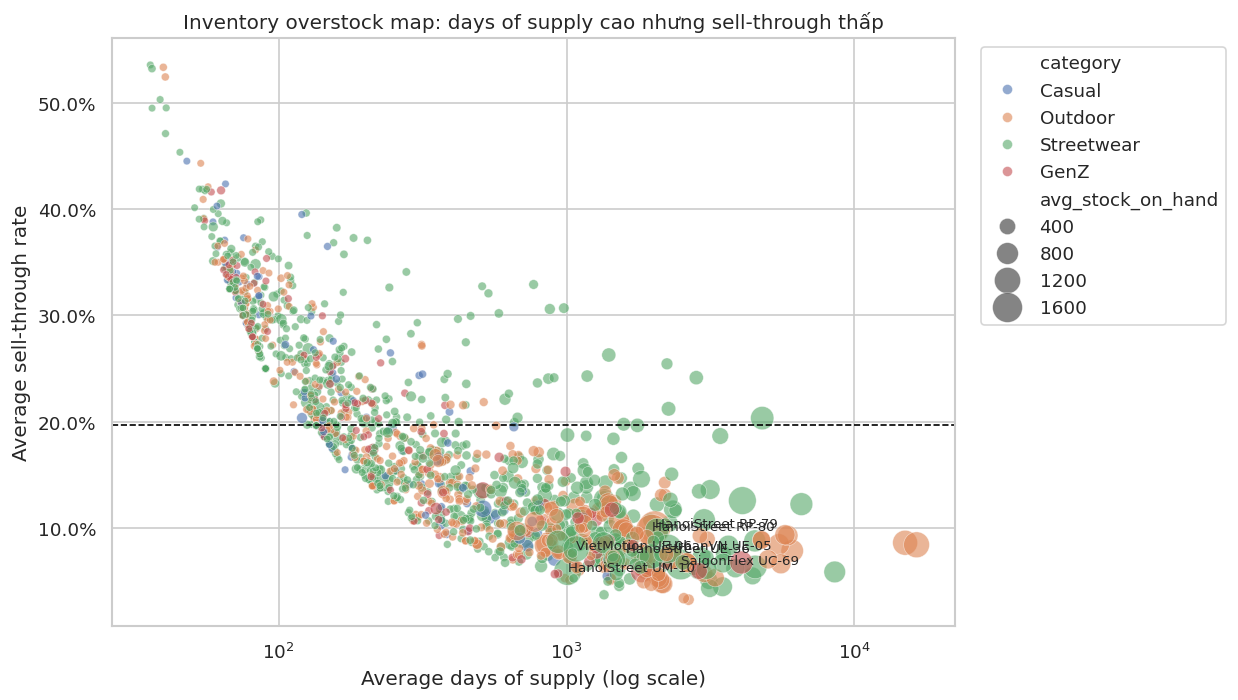

Inventory insight dùng snapshot tháng nên phù hợp cho quyết định planning tháng. Nếu muốn quyết định replenishment theo ngày, cần thêm daily stock hoặc warehouse transaction log.

### Regression model cho inventory: dự báo units_sold tháng tới

,model,train_rows,test_rows,mae,rmse,r2
0,HistGradientBoostingRegressor,"52,715","4,394",3.6255,6.6096,0.8723
1,Naive: current month units_sold,"52,715","4,394",4.2761,8.3991,0.7938


### Feature có tín hiệu mạnh nhất với units_sold tháng tới

,feature,corr_with_next_units_sold
0,units_sold,0.8297
1,units_received,0.8276
2,prev_units_sold,0.7494
3,stock_on_hand,0.3913
4,days_of_supply,-0.0966
5,stockout_days,0.0947
6,fill_rate,-0.0947
7,sell_through_rate,0.0934


### SKU có nguy cơ thiếu hàng theo dự báo tháng tới

,product_name,category,stock_on_hand,units_sold,pred_next_units_sold,pred_stock_gap,fill_rate,stockout_days,days_of_supply
13804,HanoiStreet RP-08,Outdoor,14,25,52.9437,38.9437,46.7%,16,16.8000
13801,HanoiStreet RP-07,Outdoor,15,25,52.9437,37.9437,46.7%,16,18.0000
28726,MekongFit UE-13,Streetwear,27,34,33.5286,6.5286,60.0%,12,23.8000
5381,SaigonFlex UM-26,Streetwear,11,17,14.3190,3.3190,66.7%,10,19.4000
4839,SaigonFlex UM-03,Streetwear,10,14,12.7253,2.7253,80.0%,6,21.4000
12358,SaigonFlex UC-33,Streetwear,7,10,9.0235,2.0235,86.7%,4,21.0000
39548,SaigonCore RP-13,Outdoor,3,5,4.6295,1.6295,93.3%,2,18.0000
29402,MekongFit UE-30,Streetwear,3,5,3.7956,0.7956,93.3%,2,18.0000
39567,SaigonCore RP-14,Outdoor,4,5,4.6295,0.6295,93.3%,2,24.0000
38434,VietMode RS-00,Outdoor,3,1,3.2193,0.2193,100.0%,0,90.0000



        **Giải thích.** Model regression phù hợp nhất ở đây là dự báo `units_sold` tháng tới theo product-month từ tồn kho hiện tại, sell-through, stockout, nhận hàng, tháng, category và segment.
        Nó giải quyết bài toán **replenishment/stock-gap prioritization**: sản phẩm nào tháng tới có demand dự báo cao hơn stock hiện có, thay vì chỉ nhìn overstock hiện tại.
        Trên holdout từ 2022 trở đi, model đạt MAE `3.63` units và R² `0.872`, tốt hơn baseline dùng `units_sold` tháng hiện tại (MAE `4.28`, R² `0.794`).
        Không nên dùng model này để kết luận causal effect của promotion vì inventory table không có promo exposure theo tháng; muốn làm promo uplift cần nối campaign theo ngày/order hoặc thiết kế holdout.
        

In [ ]:
inv_product = (
    inventory.groupby(["product_id", "product_name", "category", "segment"], as_index=False)
    .agg(
        avg_stock_on_hand=("stock_on_hand", "mean"),
        total_units_sold_inv=("units_sold", "sum"),
        avg_units_received=("units_received", "mean"),
        avg_stockout_days=("stockout_days", "mean"),
        stockout_rate=("stockout_flag", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        reorder_rate=("reorder_flag", "mean"),
        avg_days_supply=("days_of_supply", "mean"),
        avg_sell_through=("sell_through_rate", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
    )
).merge(
    product_summary[["product_id", "revenue", "gross_margin", "promo_revenue_share", "return_rate_qty"]],
    on="product_id",
    how="left",
)

inv_product["overstock_score"] = (
    inv_product["avg_stock_on_hand"]
    * inv_product["overstock_rate"].fillna(0)
    * (1 - inv_product["avg_sell_through"].fillna(0))
)
overstock_candidates = (
    inv_product.query("avg_stock_on_hand >= avg_stock_on_hand.quantile(0.70) and overstock_rate >= 0.70")
    .sort_values("overstock_score", ascending=False)
    .head(15)
)

display(Markdown("### Ứng viên tồn lâu/tồn nhiều"))
display(
    view_table(
        overstock_candidates[
            [
                "product_name",
                "category",
                "segment",
                "avg_stock_on_hand",
                "avg_days_supply",
                "avg_sell_through",
                "overstock_rate",
                "revenue",
                "gross_margin",
                "promo_revenue_share",
                "return_rate_qty",
                "overstock_score",
            ]
        ],
        money_cols=["revenue", "gross_margin"],
        pct_cols=["avg_sell_through", "overstock_rate", "promo_revenue_share", "return_rate_qty"],
    )
)

plt.figure(figsize=(10.5, 6))
plot_inv = inv_product.dropna(subset=["avg_days_supply", "avg_sell_through"]).copy()
ax = sns.scatterplot(
    data=plot_inv,
    x="avg_days_supply",
    y="avg_sell_through",
    hue="category",
    size="avg_stock_on_hand",
    sizes=(20, 380),
    alpha=0.6,
)
ax.axhline(plot_inv["avg_sell_through"].median(), color="black", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_title("Inventory overstock map: days of supply cao nhưng sell-through thấp")
ax.set_xlabel("Average days of supply (log scale)")
ax.set_ylabel("Average sell-through rate")
ax.yaxis.set_major_formatter(lambda y, pos: fmt_pct(y))
for _, row in overstock_candidates.head(7).iterrows():
    ax.text(row["avg_days_supply"], row["avg_sell_through"], row["product_name"], fontsize=8)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
savefig("11_inventory_overstock_map.png")

readiness.to_csv(TABLE / "13_inventory_peak_readiness.csv", index=False)
overstock_candidates.to_csv(TABLE / "14_overstock_candidates.csv", index=False)
inv_product.to_csv(TABLE / "15_inventory_product_summary.csv", index=False)

display(
    Markdown(
        "Inventory insight dùng snapshot tháng nên phù hợp cho quyết định planning tháng. Nếu muốn quyết định replenishment theo ngày, cần thêm daily stock hoặc warehouse transaction log."
    )
)


from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

inventory_model_df = inventory.sort_values(["product_id", "snapshot_date"]).copy()
inventory_model_df["target_next_units_sold"] = inventory_model_df.groupby("product_id")["units_sold"].shift(-1)
inventory_model_df["prev_units_sold"] = inventory_model_df.groupby("product_id")["units_sold"].shift(1)
inventory_model_df["prev_sell_through_rate"] = inventory_model_df.groupby("product_id")["sell_through_rate"].shift(1)
inventory_model_df = inventory_model_df.dropna(
    subset=["target_next_units_sold", "prev_units_sold", "prev_sell_through_rate"]
).copy()

# 1 2 3 4 5 6
# 10 20 30 40 50 need_pred

inventory_model_features = [
    "month",
    "stock_on_hand",
    "units_received",
    "units_sold",
    "prev_units_sold",
    "stockout_days",
    "days_of_supply",
    "fill_rate",
    "stockout_flag",
    "overstock_flag",
    "reorder_flag",
    "sell_through_rate",
    "prev_sell_through_rate",
    "category",
    "segment",
]
inventory_train = inventory_model_df[inventory_model_df["snapshot_date"] < "2022-01-01"]
inventory_test = inventory_model_df[inventory_model_df["snapshot_date"] >= "2022-01-01"]

inventory_preprocess = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["category", "segment"]),
        ("num", "passthrough", [c for c in inventory_model_features if c not in ["category", "segment"]]),
    ]
)
inventory_regression_model = Pipeline(
    [
        ("prep", inventory_preprocess),
        (
            "reg",
            HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.05,
                max_leaf_nodes=31,
                random_state=42,
            ),
        ),
    ]
)
inventory_regression_model.fit(inventory_train[inventory_model_features], inventory_train["target_next_units_sold"])

inventory_test_pred = inventory_regression_model.predict(inventory_test[inventory_model_features]).clip(min=0)
inventory_baseline_pred = inventory_test["units_sold"]
inventory_model_metrics = pd.DataFrame(
    [
        {
            "model": "HistGradientBoostingRegressor",
            "train_rows": len(inventory_train),
            "test_rows": len(inventory_test),
            "mae": mean_absolute_error(inventory_test["target_next_units_sold"], inventory_test_pred),
            "rmse": root_mean_squared_error(inventory_test["target_next_units_sold"], inventory_test_pred),
            "r2": r2_score(inventory_test["target_next_units_sold"], inventory_test_pred),
        },
        {
            "model": "Naive: current month units_sold",
            "train_rows": len(inventory_train),
            "test_rows": len(inventory_test),
            "mae": mean_absolute_error(inventory_test["target_next_units_sold"], inventory_baseline_pred),
            "rmse": root_mean_squared_error(inventory_test["target_next_units_sold"], inventory_baseline_pred),
            "r2": r2_score(inventory_test["target_next_units_sold"], inventory_baseline_pred),
        },
    ]
)

inventory_feature_signal = (
    inventory_model_df[[c for c in inventory_model_features if c not in ["category", "segment"]] + ["target_next_units_sold"]]
    .corr(numeric_only=True)["target_next_units_sold"]
    .drop("target_next_units_sold")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename_axis("feature")
    .reset_index(name="corr_with_next_units_sold")
)

latest_inventory = inventory_model_df.sort_values("snapshot_date").groupby("product_id").tail(1).copy()
latest_inventory["pred_next_units_sold"] = inventory_regression_model.predict(
    latest_inventory[inventory_model_features]
).clip(min=0)
latest_inventory["pred_stock_gap"] = latest_inventory["pred_next_units_sold"] - latest_inventory["stock_on_hand"]
stock_gap_candidates = latest_inventory.sort_values("pred_stock_gap", ascending=False).head(12)

display(Markdown("### Regression model cho inventory: dự báo units_sold tháng tới"))
display(view_table(inventory_model_metrics, int_cols=["train_rows", "test_rows"]))
display(Markdown("### Feature có tín hiệu mạnh nhất với units_sold tháng tới"))
display(view_table(inventory_feature_signal.head(8)))
display(Markdown("### SKU có nguy cơ thiếu hàng theo dự báo tháng tới"))
display(
    view_table(
        stock_gap_candidates[
            [
                "product_name",
                "category",
                "stock_on_hand",
                "units_sold",
                "pred_next_units_sold",
                "pred_stock_gap",
                "fill_rate",
                "stockout_days",
                "days_of_supply",
            ]
        ],
        pct_cols=["fill_rate"],
        int_cols=["stock_on_hand", "units_sold"],
    )
)

display(
    Markdown(
        f'''
        **Giải thích.** Model regression phù hợp nhất ở đây là dự báo `units_sold` tháng tới theo product-month từ tồn kho hiện tại, sell-through, stockout, nhận hàng, tháng, category và segment.
        Nó giải quyết bài toán **replenishment/stock-gap prioritization**: sản phẩm nào tháng tới có demand dự báo cao hơn stock hiện có, thay vì chỉ nhìn overstock hiện tại.
        Trên holdout từ 2022 trở đi, model đạt MAE `{inventory_model_metrics.iloc[0]['mae']:.2f}` units và R² `{inventory_model_metrics.iloc[0]['r2']:.3f}`, tốt hơn baseline dùng `units_sold` tháng hiện tại (MAE `{inventory_model_metrics.iloc[1]['mae']:.2f}`, R² `{inventory_model_metrics.iloc[1]['r2']:.3f}`).
        Không nên dùng model này để kết luận causal effect của promotion vì inventory table không có promo exposure theo tháng; muốn làm promo uplift cần nối campaign theo ngày/order hoặc thiết kế holdout.
        '''
    )
)

inventory_model_metrics.to_csv(TABLE / "24_inventory_regression_metrics.csv", index=False)
inventory_feature_signal.to_csv(TABLE / "25_inventory_regression_feature_signal.csv", index=False)
stock_gap_candidates.to_csv(TABLE / "26_inventory_predicted_stock_gap.csv", index=False)


## 9. Tổng hợp insight và hướng kể chuyện cho report Phase 2


In [17]:
top_cat = category_summary.sort_values("gross_margin", ascending=False).iloc[0]
top_prod = top_margin.iloc[0]
highest_promo = promo_dependent.iloc[0]
riskiest_return = risk_products.iloc[0]
top_overstock = overstock_candidates.iloc[0]
peak_cat_text = ", ".join(
    f"{r.category}: tháng {int(r.month)} ({r.season_index:.2f}x)"
    for r in peak_category_month.itertuples(index=False)
)

synthesis = f'''
### Executive synthesis

1. **Profit pool tập trung ở sản phẩm/danh mục khác với volume pool.** `{top_cat['category']}` là category dẫn đầu gross margin ({fmt_money(top_cat['gross_margin'])}), còn sản phẩm margin cao nhất là `{top_prod['product_name']}` ({fmt_money(top_prod['gross_margin'])}). Top sản phẩm theo units không nên mặc định là ưu tiên scale nếu margin thấp hoặc âm.

2. **Seasonality đủ mạnh để lên lịch inventory/promotion theo category.** Peak month theo category: {peak_cat_text}. Đây là cơ sở để đặt hàng trước mùa cao điểm và kiểm soát discount theo mùa.

3. **Promotion là đòn bẩy lớn nhưng cần guardrail margin.** Các dòng item có promotion đóng góp {fmt_pct(fact['promo_revenue'].sum() / fact['line_revenue'].sum())} revenue. `{highest_promo['product_name']}` thuộc nhóm volume/revenue lớn có promo revenue share {fmt_pct(highest_promo['promo_revenue_share'])}; nếu margin thấp, promotion nên được dùng có mục tiêu thay vì scale đại trà.

4. **Return leakage nên xử lý theo nguyên nhân, không chỉ rating.** Lý do return lớn nhất là `{reason_share.iloc[0]['return_reason']}` ({fmt_pct(reason_share.iloc[0]['share'])}). Product risk cao nhất trong nhóm volume lớn là `{riskiest_return['product_name']}` với return rate {fmt_pct(riskiest_return['return_rate_qty'])} và refund share {fmt_pct(riskiest_return['refund_share'])}.

5. **Demand theo vùng có thể guide campaign, nhưng chưa đủ để quyết định kho vùng.** `orders.zip` + `geography` cho thấy demand concentration theo region/city; tuy nhiên inventory không có dimension region/warehouse.

6. **Inventory có hai bài toán song song: bảo vệ peak demand và giảm overstock.** Sản phẩm overstock nổi bật là `{top_overstock['product_name']}` với days of supply trung bình {top_overstock['avg_days_supply']:.1f} và sell-through {fmt_pct(top_overstock['avg_sell_through'])}. Nhóm high-demand stockout nên được ưu tiên replenishment trước peak month.

### Cách đưa vào report

- Mở bằng nghịch lý: "best seller chưa chắc là profit driver".
- Sau đó nối sang seasonality: profit driver cần được bảo vệ bằng inventory đúng tháng.
- Tiếp theo là channel/promotion: scale channel nào và sản phẩm nào cần guardrail discount.
- Kết thúc bằng operational actions: giảm return theo nguyên nhân, xử lý overstock, và tạo feature cho forecasting Phase 3.
'''

display(Markdown(synthesis))

with open(WORK / "phase2_product_insights_summary.md", "w", encoding="utf-8") as f:
    f.write(synthesis.strip() + "\n")

print("Saved figures to:", FIG)
print("Saved summary tables to:", TABLE)
print("Saved markdown summary to:", WORK / "phase2_product_insights_summary.md")



### Executive synthesis

1. **Profit pool tập trung ở sản phẩm/danh mục khác với volume pool.** `Streetwear` là category dẫn đầu gross margin (1.74B), còn sản phẩm margin cao nhất là `SaigonFlex UM-43` (130.46M). Top sản phẩm theo units không nên mặc định là ưu tiên scale nếu margin thấp hoặc âm.

2. **Seasonality đủ mạnh để lên lịch inventory/promotion theo category.** Peak month theo category: GenZ: tháng 6 (1.75x), Streetwear: tháng 5 (1.55x), Casual: tháng 5 (1.51x), Outdoor: tháng 12 (1.38x). Đây là cơ sở để đặt hàng trước mùa cao điểm và kiểm soát discount theo mùa.

3. **Promotion là đòn bẩy lớn nhưng cần guardrail margin.** Các dòng item có promotion đóng góp 33.1% revenue. `HanoiStreet RP-82` thuộc nhóm volume/revenue lớn có promo revenue share 51.0%; nếu margin thấp, promotion nên được dùng có mục tiêu thay vì scale đại trà.

4. **Return leakage nên xử lý theo nguyên nhân, không chỉ rating.** Lý do return lớn nhất là `wrong_size` (35.0%). Product risk cao nhất trong nhóm volume lớn là `UrbanVN RP-12` với return rate 6.1% và refund share 5.7%.

5. **Demand theo vùng có thể guide campaign, nhưng chưa đủ để quyết định kho vùng.** `orders.zip` + `geography` cho thấy demand concentration theo region/city; tuy nhiên inventory không có dimension region/warehouse.

6. **Inventory có hai bài toán song song: bảo vệ peak demand và giảm overstock.** Sản phẩm overstock nổi bật là `HanoiStreet RP-79` với days of supply trung bình 2024.5 và sell-through 10.1%. Nhóm high-demand stockout nên được ưu tiên replenishment trước peak month.

### Cách đưa vào report

- Mở bằng nghịch lý: "best seller chưa chắc là profit driver".
- Sau đó nối sang seasonality: profit driver cần được bảo vệ bằng inventory đúng tháng.
- Tiếp theo là channel/promotion: scale channel nào và sản phẩm nào cần guardrail discount.
- Kết thúc bằng operational actions: giảm return theo nguyên nhân, xử lý overstock, và tạo feature cho forecasting Phase 3.


Saved figures to: /home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm/group_job/figures
Saved summary tables to: /home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm/group_job/tables
Saved markdown summary to: /home/thangquang09/code/vinuni_hackathon_lag_rolling_lgbm/group_job/phase2_product_insights_summary.md
